# Análisis Predictivo de Ingresos de Freelancers en Upwork

## MIT Summer Program - Uruguay 2026

### Proyecto de Machine Learning

Este notebook presenta un análisis predictivo para estimar los ingresos potenciales de freelancers en la plataforma Upwork, utilizando datos reales del dataset de Kaggle.

**Autores:**  Abril Ocampo, Camilo Castellano, Gerardo Gonzalez

**Dataset:** [Upwork Dataset](https://www.kaggle.com/datasets) - ~60,000 registros de trabajos freelance de la plataforma Upwork

## Objetivo del Análisis

Desarrollar UN modelo predictivo:

### Modelo 1: Predicción de Ingresos (Regresión)
Estimar la **tarifa horaria promedio** (`Hourly_rate`) que puede cobrar un freelancer basándose en las principales características que se reflejan en el dataset:
- **Skills**
- **Search_Keyword**
- **EX_level_demand**
- **País del cliente**, etc.



### Modelos Recomendados

| Objetivo | Tipo | Modelos Recomendados |
|----------|------|---------------------|
| Predicción de Ingresos | Regresión | **Gradient Boosting**, Random Forest (R² ~0.18-0.20) |


### Metodología

1. **Carga y limpieza robusta** - Dataset de Upwork filtrado por trabajos "Hourly" y control de calidad de datos.
2. **Definición de Target** - Variable `Hourly_rate` calculada como el promedio entre `Start_rate` y `End_rate` (solo registros con ambos datos).
3. **Feature Engineering** - One-Hot Encoding de skills, países y keywords; eliminación de outliers (IQR).
4. **Entrenamiento** - Modelos de regresión optimizados con Grid Search implícito.

In [2]:
# ============================================================
# PASO 0: Cargar librerías y Dataset de Upwork
# ============================================================

# Standard Library Imports
import os
import warnings
from collections import Counter

# Third-Party Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from matplotlib.patches import Patch

# Scikit-Learn Imports
try:
    from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
    from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
except ImportError:
    print("⚠️ Scikit-Learn no está instalado o falló la importación.")

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt


print("="*70)
print("📚 CARGA DE LIBRERÍAS COMPLETADA")
print("="*70)

print("="*70)
print("CARGA DEL DATASET DE UPWORK FREELANCERS")
print("="*70)

# Try to load the dataset from local file (Excel or CSV)
# Prioritize local execution compatibility

# Define candidate files
excel_file = 'Final_Upwork_Dataset.xlsx'
csv_file = 'Final_Upwork_Dataset.csv'

if os.path.exists(excel_file):
    print(f"\n📂 Cargando archivo Excel: {excel_file}")
    df_raw = pd.read_excel(excel_file)
elif os.path.exists(csv_file):
    print(f"\n📂 Cargando archivo CSV: {csv_file}")
    df_raw = pd.read_csv(csv_file)
else:
    # Fallback for Colab environment if file not found locally
    print("\n⚠️ Archivo local no encontrado. Intentando rutas de Colab...")
    colab_csv_file = r"/content/drive/MyDrive/Final_Upwork_Dataset.csv"
    if os.path.exists(colab_csv_file):
         print(f"📂 Cargando archivo desde Colab: {colab_csv_file}")
         df_raw = pd.read_csv(colab_csv_file)
    else:
        raise FileNotFoundError("❌ No se encontró el dataset (ni .xlsx local, ni .csv local, ni ruta Colab).")

print(f"\n✅ Dataset cargado exitosamente!")
print(f"   📊 Filas originales: {df_raw.shape[0]:,}")
print(f"   📋 Columnas: {df_raw.shape[1]}")

📚 CARGA DE LIBRERÍAS COMPLETADA
CARGA DEL DATASET DE UPWORK FREELANCERS

📂 Cargando archivo Excel: Final_Upwork_Dataset.xlsx

✅ Dataset cargado exitosamente!
   📊 Filas originales: 63,950
   📋 Columnas: 41


In [3]:
df_raw.head()

,Job Title,Job_URL,EX_level_demand,Time_Limitation,Search_Keyword,Posted_from,Description,Category1_URL_search,Category_1,highlight,...,Client_Country,Connects_Num,New_Connects_Num,Rating,Feedback_Num,Payment_type,Job_Cost,Hourly_Rate,Start_rate,End_rate
0,Power bi specialist freelance,https://www.upwork.com/jobs/Power-specialist-f...,Expert,NaN,Data_science,5 minutes ago,Already data pooled and designed. Need to refi...,https://www.upwork.com/nx/jobs/search/?ontolog...,Data Analysis,data,...,United States,6.0,12.0,NaN,0.0,Fixed-price,2500.0,NaN,0.0,NaN
1,Case Study (on-demand delivery startup),https://www.upwork.com/jobs/Case-Study-demand-...,Intermediate,NaN,Data_science,5 minutes ago,"Hi,\n\nWould you be able to help me do a case-...",https://www.upwork.com/nx/jobs/search/?ontolog...,Google Data Studio,Google Data Studio,...,Canada,4.0,8.0,5.000000,1.0,Fixed-price,200.0,NaN,0.0,NaN
2,"File Maker Pro Reports, Charts, Query and Ongo...",https://www.upwork.com/jobs/File-Maker-Pro-Rep...,Intermediate,"3 to 6 months, Less than 30 hrs/week",Data_science,9 minutes ago,NITIAL PROJECT\n\nSet up Monthly Report mimick...,https://www.upwork.com/nx/jobs/search/?ontolog...,Report Writing,NaN,...,United States,6.0,12.0,5.000000,1.0,Hourly,NaN,40,40.0,NaN
3,Implementation of EleutherAI/gpt-neox-20b,https://www.upwork.com/jobs/Implementation-Ele...,Expert,"3 to 6 months, Less than 30 hrs/week",Data_science,12 minutes ago,"As a first step, you will implement the instal...",https://www.upwork.com/nx/jobs/search/?ontolog...,Machine Learning Model,NaN,...,Canada,6.0,12.0,4.935536,26.0,Hourly,NaN,$35.00-$100.00,35.0,100.0
4,BI and Data Engineer for Upwork Finance System...,https://www.upwork.com/jobs/and-span-Data-span...,Expert,"More than 6 months, 30+ hrs/week",Data_science,14 minutes ago,The Upwork Finance Systems team is looking for...,https://www.upwork.com/nx/jobs/search/?ontolog...,Data Analysis,Data,...,United States,6.0,12.0,4.942242,12512.0,Hourly,NaN,NaN,0.0,NaN


In [4]:
# ============================================================
# PASO 0.1: Análisis de valores faltantes (NA)
# ============================================================
print("\n" + "="*70)
print("ANÁLISIS DE VALORES FALTANTES (NA)")
print("="*70)

na_analysis = pd.DataFrame({
    'Columna': df_raw.columns,
    'NA_count': df_raw.isnull().sum().values,
    'NA_pct': (df_raw.isnull().sum() / len(df_raw) * 100).values
}).sort_values('NA_pct', ascending=False)

print("\n📊 Porcentaje de NA por columna:")
for _, row in na_analysis.iterrows():
    status = "✅" if row['NA_pct'] < 30 else "⚠️" if row['NA_pct'] < 50 else "❌"
    print(f"   {status} {row['Columna']}: {row['NA_pct']:.1f}% NA ({int(row['NA_count']):,} valores)")

# Filtrar columnas con menos del 50% de NA, PERO conservar End_rate y Hourly_Rate para la variable objetivo
MAX_NA_PCT = 50
cols_to_keep = na_analysis[na_analysis['NA_pct'] < MAX_NA_PCT]['Columna'].tolist()

# Asegurarse de incluir End_rate aunque tenga más de 50% NA (necesario para variable objetivo)
if 'End_rate' not in cols_to_keep and 'End_rate' in df_raw.columns:
    cols_to_keep.append('End_rate')
    print("\n⚠️ End_rate agregada manualmente (necesaria para variable objetivo)")

# Asegurarse de incluir Hourly_Rate aunque tenga más de 50% NA (necesario para variable objetivo)
if 'Hourly_Rate' not in cols_to_keep and 'Hourly_Rate' in df_raw.columns:
    cols_to_keep.append('Hourly_Rate')
    print("⚠️ Hourly_Rate agregada manualmente (necesaria para variable objetivo)")

cols_dropped = [col for col in df_raw.columns if col not in cols_to_keep]

print(f"\n🔧 Umbral de NA: {MAX_NA_PCT}%")
print(f"   ✅ Columnas conservadas: {len(cols_to_keep)}")
print(f"   ❌ Columnas eliminadas por exceso de NA: {len(cols_dropped)}")
if cols_dropped:
    print(f"      {cols_dropped}")

df = df_raw[cols_to_keep].copy()

# ============================================================
# PASO 0.2: Filtrar solo trabajos con pago por hora (HOURLY)
# ============================================================
print("\n" + "="*70)
print("FILTRO: SOLO TRABAJOS CON PAGO POR HORA")
print("="*70)

# Buscar columna de tipo de pago (puede ser Payment_Type o Payment_type)
payment_col = None
for col in df.columns:
    if 'payment' in col.lower() and 'type' in col.lower():
        payment_col = col
        break

if payment_col:
    print(f"\n📊 Columna encontrada: '{payment_col}'")
    print(f"Distribución de tipos de pago:")
    print(df[payment_col].value_counts())

    # Filtrar solo hourly
    df = df[df[payment_col].str.lower().str.contains('hourly', na=False)]
    print(f"\n✅ Filas después de filtrar por 'hourly': {len(df):,}")
else:
    print("⚠️ Columna de tipo de pago no encontrada")


ANÁLISIS DE VALORES FALTANTES (NA)

📊 Porcentaje de NA por columna:
   ❌ Enterprise_Client: 99.9% NA (63,897 valores)
   ❌ Category_9: 74.2% NA (47,469 valores)
   ❌ Category9_URL_search: 74.2% NA (47,469 valores)
   ❌ Job_Cost: 68.5% NA (43,837 valores)
   ❌ Category_8: 68.0% NA (43,514 valores)
   ❌ Category8_URL_search: 68.0% NA (43,514 valores)
   ❌ Time_Limitation: 64.0% NA (40,916 valores)
   ❌ Category7_URL_search: 60.6% NA (38,758 valores)
   ❌ Category_7: 60.6% NA (38,758 valores)
   ❌ End_rate: 59.4% NA (37,987 valores)
   ❌ Hourly_Rate: 58.5% NA (37,380 valores)
   ❌ Rating: 52.2% NA (33,357 valores)
   ❌ Category_6: 51.0% NA (32,643 valores)
   ❌ Category6_URL_search: 51.0% NA (32,643 valores)
   ⚠️ Category5_URL_search: 38.1% NA (24,372 valores)
   ⚠️ Category_5: 38.1% NA (24,372 valores)
   ✅ Category4_URL_search: 25.7% NA (16,407 valores)
   ✅ Category_4: 25.7% NA (16,407 valores)
   ✅ highlight: 21.6% NA (13,819 valores)
   ✅ Category3_URL_search: 14.0% NA (8,953 valor

In [5]:
print("\n" + "="*70)
print("LIMPIEZA ADICIONAL: ELIMINAR COLUMNAS CON 'URL'")
print("="*70)

# Identificar y eliminar columnas que contienen 'URL' en su nombre
url_cols = [col for col in df.columns if 'URL' in col]

if url_cols:
    print(f"\n🗑️ Removiendo las siguientes columnas con 'URL' en su nombre: {url_cols}")
    df = df.drop(columns=url_cols)
    print(f"✅ Columnas con 'URL' eliminadas. El DataFrame ahora tiene {df.shape[1]} columnas.")
else:
    print("\nℹ️ No se encontraron columnas con 'URL' en su nombre para eliminar.")

print(f"\n📊 Dimensiones actuales del DataFrame: {df.shape[0]:,} filas, {df.shape[1]} columnas")


LIMPIEZA ADICIONAL: ELIMINAR COLUMNAS CON 'URL'

🗑️ Removiendo las siguientes columnas con 'URL' en su nombre: ['Category5_URL_search', 'Category4_URL_search', 'Category3_URL_search', 'Category2_URL_search', 'Category1_URL_search', 'Job_URL']
✅ Columnas con 'URL' eliminadas. El DataFrame ahora tiene 23 columnas.

📊 Dimensiones actuales del DataFrame: 40,333 filas, 23 columnas


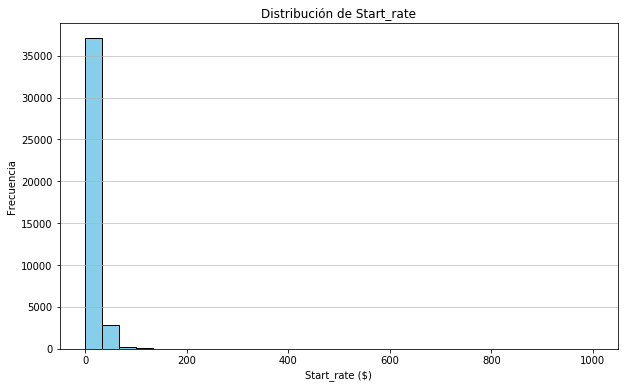

In [6]:


plt.figure(figsize=(10, 6))
plt.hist(df['Start_rate'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de Start_rate')
plt.xlabel('Start_rate ($)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [7]:
# ============================================================
# PASO 0.3: Crear variable objetivo (Hourly_rate) a partir de la columna 'Hourly_Rate' (string)
# ============================================================
print("\n" + "="*70)
print("CREAR VARIABLE OBJETIVO: Hourly_rate (a partir de columna string)")
print("="*70)

# Función para parsear el string de Hourly_Rate
def parse_hourly_rate_string(rate_str):
    if pd.isna(rate_str) or rate_str == 'Not specified':
        return np.nan
    s = str(rate_str).replace('$', '').strip()
    if '-' in s:
        try:
            start, end = map(float, s.split('-'))
            return (start + end) / 2
        except ValueError:
            return np.nan
    else:
        try:
            return float(s)
        except ValueError:
            return np.nan

# Aplicar la función a la columna 'Hourly_Rate' para crear la nueva variable numérica
df['Hourly_rate_numeric'] = df['Hourly_Rate'].apply(parse_hourly_rate_string)

# Filtrar solo registros donde Hourly_rate_numeric es válido (> 0 y no NaN)
initial_rows = len(df)
df = df[df['Hourly_rate_numeric'].notna() & (df['Hourly_rate_numeric'] > 0)].copy()
print(f"\n✅ Registros con Hourly_rate_numeric válido: {len(df):,}")
print(f"   Filas restantes después de filtrar: {len(df):,} (se eliminaron {initial_rows - len(df):,} filas)")

# Renombrar para usar como variable objetivo principal
df['Hourly_rate'] = df['Hourly_rate_numeric']

print(f"\n📈 Estadísticas de la nueva variable objetivo (Hourly_rate):")
print(f"   Min: ${df['Hourly_rate'].min():.2f}")
print(f"   Max: ${df['Hourly_rate'].max():.2f}")
print(f"   Media: ${df['Hourly_rate'].mean():.2f}")
print(f"   Mediana: ${df['Hourly_rate'].median():.2f}")




CREAR VARIABLE OBJETIVO: Hourly_rate (a partir de columna string)

✅ Registros con Hourly_rate_numeric válido: 26,570
   Filas restantes después de filtrar: 26,570 (se eliminaron 13,763 filas)

📈 Estadísticas de la nueva variable objetivo (Hourly_rate):
   Min: $3.00
   Max: $999.00
   Media: $30.56
   Mediana: $24.00


In [8]:
# ============================================================
# PASO 0.4: Eliminar outliers en Hourly_rate
# ============================================================
print("\n" + "="*70)
print("LIMPIEZA: ELIMINACIÓN DE OUTLIERS EN HOURLY_RATE")
print("="*70)

# Eliminar outliers usando IQR (método de cuartiles)
Q1 = df['Hourly_rate'].quantile(0.25)
Q3 = df['Hourly_rate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = max(0, Q1 - 1.5 * IQR) # Aseguramos que el límite inferior no sea negativo
upper_bound = Q3 + 1.5 * IQR

outliers_count = len(df[(df['Hourly_rate'] < lower_bound) | (df['Hourly_rate'] > upper_bound)])
df = df[(df['Hourly_rate'] >= lower_bound) & (df['Hourly_rate'] <= upper_bound)]

print(f"\n🔧 Eliminación de outliers (método IQR):")
print(f"   Q1: ${Q1:.2f}, Q3: ${Q3:.2f}, IQR: ${IQR:.2f}")
print(f"   Rango aceptado: ${lower_bound:.2f} - ${upper_bound:.2f}")
print(f"   ❌ Outliers eliminados: {outliers_count:,}")

print(f"\n📈 Estadísticas de Hourly_rate DESPUÉS de eliminar outliers:")
print(f"   Min: ${df['Hourly_rate'].min():.2f}")
print(f"   Max: ${df['Hourly_rate'].max():.2f}")
print(f"   Media: ${df['Hourly_rate'].mean():.2f}")
print(f"   Mediana: ${df['Hourly_rate'].median():.2f}")


LIMPIEZA: ELIMINACIÓN DE OUTLIERS EN HOURLY_RATE

🔧 Eliminación de outliers (método IQR):
   Q1: $15.00, Q3: $37.50, IQR: $22.50
   Rango aceptado: $0.00 - $71.25
   ❌ Outliers eliminados: 1,454

📈 Estadísticas de Hourly_rate DESPUÉS de eliminar outliers:
   Min: $3.00
   Max: $71.00
   Media: $26.06
   Mediana: $22.50


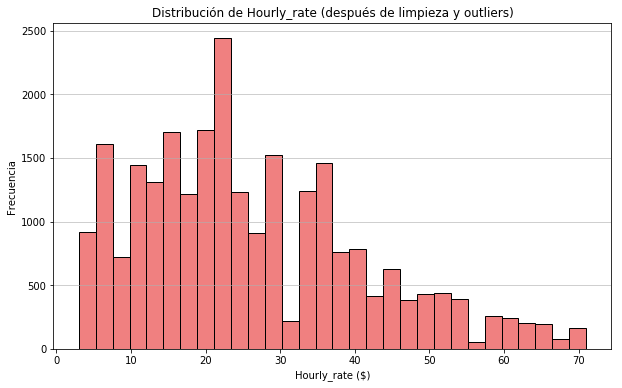

In [9]:


plt.figure(figsize=(10, 6))
plt.hist(df['Hourly_rate'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribución de Hourly_rate (después de limpieza y outliers)')
plt.xlabel('Hourly_rate ($)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [10]:
# ============================================================
# RESUMEN FINAL DEL DATASET LIMPIO
# ============================================================
print("\n" + "="*70)
print("🎯 RESUMEN DEL DATASET LIMPIO (PARA ENTRENAR MODELOS)")
print("="*70)
print(f"\n✅ Dataset final listo para modelar:")
print(f"   📊 Filas: {df.shape[0]:,}")
print(f"   📋 Columnas: {df.shape[1]}")
print(f"\n🎯 Variable objetivo: Hourly_rate")

print(f"\n📋 Columnas del dataset limpio:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2}. {col}")

print(f"\n📊 Primeras 5 filas:")
display(df.head())


🎯 RESUMEN DEL DATASET LIMPIO (PARA ENTRENAR MODELOS)

✅ Dataset final listo para modelar:
   📊 Filas: 25,116
   📋 Columnas: 25

🎯 Variable objetivo: Hourly_rate

📋 Columnas del dataset limpio:
    1. Category_5
    2. Category_4
    3. highlight
    4. Category_3
    5. EX_level_demand
    6. Category_2
    7. Spent($)
    8. Category_1
    9. Client_Country
   10. Posted_from
   11. Description
   12. Search_Keyword
   13. Payment_Situation
   14. Connects_Num
   15. New_Connects_Num
   16. Applicants_Num
   17. Feedback_Num
   18. Payment_type
   19. Start_rate
   20. Job Title
   21. Freelancers_Num
   22. End_rate
   23. Hourly_Rate
   24. Hourly_rate_numeric
   25. Hourly_rate

📊 Primeras 5 filas:


,Category_5,Category_4,highlight,Category_3,EX_level_demand,Category_2,Spent($),Category_1,Client_Country,Posted_from,...,Applicants_Num,Feedback_Num,Payment_type,Start_rate,Job Title,Freelancers_Num,End_rate,Hourly_Rate,Hourly_rate_numeric,Hourly_rate
2,NaN,NaN,NaN,NaN,Intermediate,Custom Graphics,200.0,Report Writing,United States,9 minutes ago,...,Less than 5,1.0,Hourly,40.0,"File Maker Pro Reports, Charts, Query and Ongo...",1,NaN,40,40.0,40.0
3,NaN,NaN,NaN,Python,Expert,Machine Learning,200000.0,Machine Learning Model,Canada,12 minutes ago,...,Less than 5,26.0,Hourly,35.0,Implementation of EleutherAI/gpt-neox-20b,1,100.0,$35.00-$100.00,67.5,67.5
8,Microsoft Visual Studio,Azure DevOps,Data,ETL,Intermediate,Microsoft Azure,0.0,SQL,Poland,22 minutes ago,...,Less than 5,0.0,Hourly,25.0,Azure Data Factory specialist,1,35.0,$25.00-$35.00,30.0,30.0
10,NaN,NaN,Data Extraction,NaN,Intermediate,ETL,0.0,Data Extraction,Bolivia,33 minutes ago,...,Less than 5,0.0,Hourly,8.0,Descarga e Interrelación entre Bases de Datos,1,25.0,$8.00-$25.00,16.5,16.5
12,NaN,Market Research,data,Statistics,Intermediate,SurveyMonkey,10000.0,Data Analysis,United States,37 minutes ago,...,Less than 5,185.0,Hourly,45.0,Culture Survey data analysis and theme extraction,1,73.0,$45.00-$73.00,59.0,59.0


In [11]:
category_cols_up_to_3 = [f'Category_{i}' for i in range(1, 4) if f'Category_{i}' in df.columns]

if category_cols_up_to_3:
    # Count rows where ALL of the specified category columns are not null
    num_observations = df[category_cols_up_to_3].notna().all(axis=1).sum()
    print(f"Número de observaciones con valores EN TODAS las columnas hasta Category 3 (sin NaN): {num_observations:,}")
else:
    print("No se encontraron columnas de categoría (Category_1 a Category_3) en el DataFrame.")

Número de observaciones con valores EN TODAS las columnas hasta Category 3 (sin NaN): 21,439


In [12]:
print("\n" + "="*70)
print("LIMPIEZA ADICIONAL: CONSERVAR SOLO CATEGORY_1 A CATEGORY_3")
print("="*70)

cols_to_drop_for_categories = [f'Category_{i}' for i in range(4, 6) if f'Category_{i}' in df.columns]

if cols_to_drop_for_categories:
    print(f"\n🗑️ Removiendo las siguientes columnas de categoría: {cols_to_drop_for_categories}")
    df = df.drop(columns=cols_to_drop_for_categories)
    print(f"✅ Columnas eliminadas. El DataFrame ahora tiene {df.shape[1]} columnas.")
else:
    print("\nℹ️ No se encontraron columnas de categoría (Category_4 o Category_5) para eliminar.")

print(f"\n📊 Dimensiones actuales del DataFrame: {df.shape[0]:,} filas, {df.shape[1]} columnas")


LIMPIEZA ADICIONAL: CONSERVAR SOLO CATEGORY_1 A CATEGORY_3

🗑️ Removiendo las siguientes columnas de categoría: ['Category_4', 'Category_5']
✅ Columnas eliminadas. El DataFrame ahora tiene 23 columnas.

📊 Dimensiones actuales del DataFrame: 25,116 filas, 23 columnas


# Data exploration and Preprocessing

ANÁLISIS DE DATOS PARA PREDICCIÓN DE INGRESOS

🎯 Variable objetivo (ingresos): Hourly_rate
🔧 Variable de categoría/keyword: Search_Keyword

ESTADÍSTICAS DESCRIPTIVAS DE TARIFA POR HORA

📈 Estadísticas de Hourly_rate:
count    25116.000000
mean        26.059902
std         15.011639
min          3.000000
25%         15.000000
50%         22.500000
75%         35.000000
max         71.000000
Name: Hourly_rate, dtype: float64


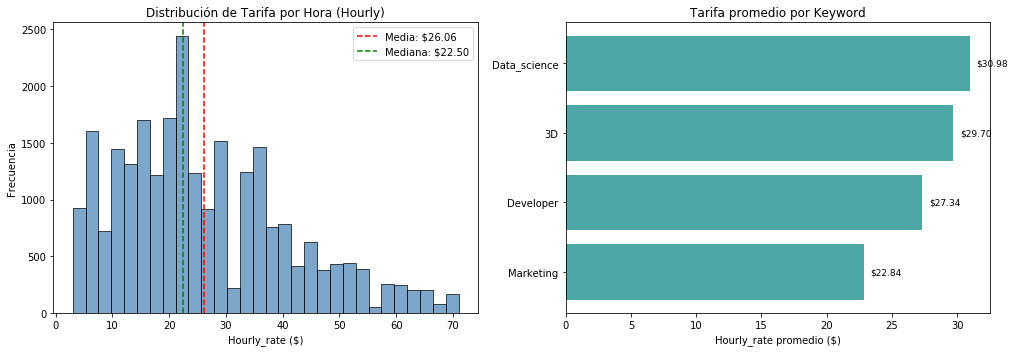


TARIFA PROMEDIO POR NIVEL DE EXPERIENCIA
                 Media ($)  Mediana ($)      N
EX_level_demand                               
Entry level          19.83         16.5   2222
Expert               30.10         30.0   8422
Intermediate         24.04         22.5  11706

CORRELACIONES CON TARIFA POR HORA

📊 Correlaciones con Hourly_rate:
   Hourly_rate_numeric: 1.0000
   End_rate: 0.9711
   Start_rate: 0.8768
   Spent($): 0.0168
   Freelancers_Num: -0.0174
   Feedback_Num: -0.0326
   New_Connects_Num: -0.0788
   Connects_Num: -0.0788


In [13]:
# ============================================================
# PASO 1: Exploración de datos para el modelo predictivo
# ============================================================

print("="*70)
print("ANÁLISIS DE DATOS PARA PREDICCIÓN DE INGRESOS")
print("="*70)

# Identificar columnas relevantes
# Usar 'Hourly_rate' que ya fue procesada y es numérica
income_col = 'Hourly_rate'
skills_col = 'Search_Keyword' if 'Search_Keyword' in df.columns else None

print(f"\n🎯 Variable objetivo (ingresos): {income_col}")
print(f"🔧 Variable de categoría/keyword: {skills_col}")

# Asegurarse de que income_col sea numérica (ya debería serlo después del PASO 0.3 y 0.4)
df[income_col] = pd.to_numeric(df[income_col], errors='coerce')

# Estadísticas descriptivas
print("\n" + "="*70)
print("ESTADÍSTICAS DESCRIPTIVAS DE TARIFA POR HORA")
print("="*70)

print(f"\n📈 Estadísticas de {income_col}:")
print(df[income_col].describe())

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de tarifas
axes[0].hist(df[income_col].values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel(f'{income_col} ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title(f'Distribución de Tarifa por Hora (Hourly)')
axes[0].axvline(df[income_col].mean(), color='red', linestyle='--', label=f'Media: ${df[income_col].mean():.2f}')
axes[0].axvline(df[income_col].median(), color='green', linestyle='--', label=f'Mediana: ${df[income_col].median():.2f}')
axes[0].legend()

# Por Search_Keyword
if skills_col and skills_col in df.columns:
    # Asegurarse de que Search_Keyword no tenga NaNs antes de agrupar
    keyword_avg = df.dropna(subset=[skills_col]).groupby(skills_col)[income_col].mean().sort_values(ascending=True)
    # Limitar a las top N keywords para visualización si hay muchas
    if len(keyword_avg) > 10:
        keyword_avg = keyword_avg.tail(10) # Mostrar las 10 keywords con tarifas más altas

    bars = axes[1].barh(keyword_avg.index, keyword_avg.values, color='teal', alpha=0.7)
    axes[1].set_xlabel(f'{income_col} promedio ($)')
    axes[1].set_title('Tarifa promedio por Keyword')
    for i, (kw, val) in enumerate(zip(keyword_avg.index, keyword_avg.values)):
        axes[1].text(val + 0.5, i, f'${val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Análisis por nivel de experiencia
if 'EX_level_demand' in df.columns:
    print("\n" + "="*70)
    print("TARIFA PROMEDIO POR NIVEL DE EXPERIENCIA")
    print("="*70)
    # Asegurarse de que EX_level_demand no tenga NaNs antes de agrupar
    exp_stats = df.dropna(subset=['EX_level_demand']).groupby('EX_level_demand')[income_col].agg(['mean', 'median', 'count'])
    exp_stats.columns = ['Media ($)', 'Mediana ($)', 'N']
    print(exp_stats.round(2))

# Correlaciones numéricas
print("\n" + "="*70)
print("CORRELACIONES CON TARIFA POR HORA")
print("="*70)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if income_col in numeric_cols:
    correlations = df[numeric_cols].corr()[income_col].drop(income_col).sort_values(ascending=False)
    print(f"\n📊 Correlaciones con {income_col}:")
    for col, corr in correlations.items():
        if abs(corr) > 0.01:  # Solo mostrar correlaciones relevantes
            print(f"   {col}: {corr:.4f}")

## 📖 The Story of Our Problem: Freelancer Challenges and Our Solution (ABT)

### **A: Action**

Our goal is to build a predictive model that helps freelancers navigate the competitive Upwork landscape by estimating their potential hourly rates and quantifying job opportunities. This proactive approach aims to empower them to make informed decisions and enhance their job search effectiveness.

### **B: Background**

In today's globalized economy, the freelance market is booming, with countless talented individuals seeking work on platforms like Upwork. However, this growth has led to significant challenges: freelancers often struggle with setting appropriate rates, understanding the true demand for their skills, and assessing the competitiveness of various job postings. They frequently face the daunting task of sifting through thousands of jobs, unsure of which opportunities offer the best combination of fair compensation and a high chance of success. This lack of clear, data-driven guidance leads to underpricing, wasted effort on highly competitive bids, and a general sense of uncertainty in their professional trajectory.

### **T: Thesis**

**Therefore, we hypothesize that by developing a dual predictive model—one for hourly rate estimation and another for an 'opportunity score'—we can provide freelancers with the crucial insights needed to overcome these obstacles.** This model will leverage historical job data to not only suggest competitive hourly rates based on skills and experience but also to calculate a unique opportunity score. This score will account for factors like applicant volume, client verification, and job connection costs, offering a holistic view of a job's potential success. Our work aims to transform the freelance job search from a guessing game into a strategic, data-informed process, ultimately improving job satisfaction and earning potential for freelancers worldwide.

### ✨ Enfoque de Alto Nivel

Nuestra solución se basa en dos modelos predictivos principales:

#### **1. Modelo de Predicción de Ingresos**
*   **Tarea ML:** Regresión
*   **Objetivo (Output):** Predecir la **Tarifa Horaria Promedio** (`Hourly_rate`)
*   **Entradas (Inputs):**
    *   **Skills:** (e.g., 'Python', 'Data Analysis', 'Machine Learning')
    *   **Keyword de Búsqueda:** (e.g., 'Data science', 'Developer', 'Marketing')
    *   **Nivel de Experiencia:** (e.g., 'Entry Level', 'Intermediate', 'Expert')
    *   **Factores del Cliente:** País del cliente, Verificación de pago., etc.


# Prediction models

# Data Visualization


VISUALIZATION OF THE TARGET VARIABLE: HOURLY_RATE


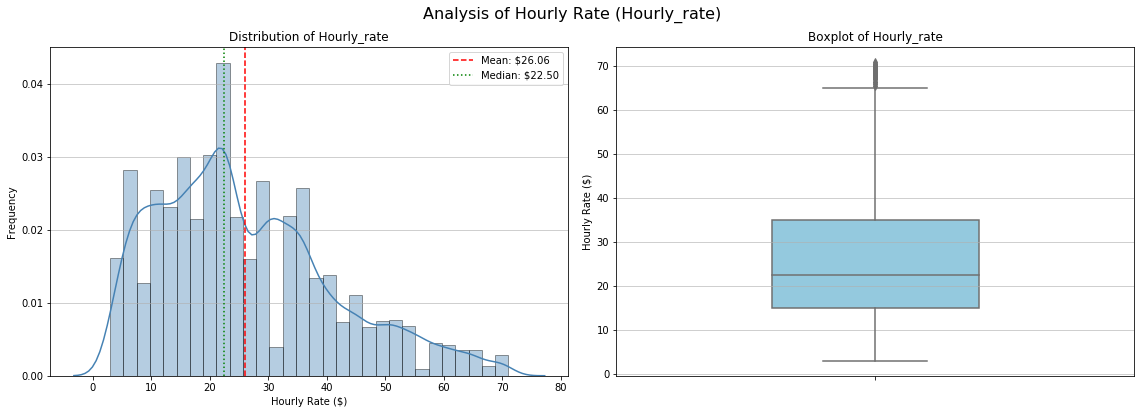


INITIAL CONCLUSIONS ON HOURLY_RATE

📈 The average hourly rate is $26.06.
   The median is $22.50, indicating a slightly skewed distribution.
   The range of rates is mostly between $15.00 and $35.00.


In [14]:
print("\n" + "="*70)
print("VISUALIZATION OF THE TARGET VARIABLE: HOURLY_RATE")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analysis of Hourly Rate (Hourly_rate)', fontsize=16)

# Histograma de Hourly_rate
# Compatibility check for older seaborn versions
if hasattr(sns, 'histplot'):
    sns.histplot(df['Hourly_rate'], bins=30, kde=True, ax=axes[0], color='steelblue', edgecolor='black')
else:
    # Fallback to distplot for seaborn < 0.11.0
    sns.distplot(df['Hourly_rate'], bins=30, kde=True, ax=axes[0], color='steelblue', hist_kws={'edgecolor': 'black'})

axes[0].set_title('Distribution of Hourly_rate')
axes[0].set_xlabel('Hourly Rate ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Hourly_rate'].mean(), color='red', linestyle='--', label=f'Mean: ${df["Hourly_rate"].mean():.2f}')
axes[0].axvline(df['Hourly_rate'].median(), color='green', linestyle=':', label=f'Median: ${df["Hourly_rate"].median():.2f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.75)

# Boxplot de Hourly_rate
if hasattr(sns, 'boxplot'):
     sns.boxplot(y=df['Hourly_rate'], ax=axes[1], color='skyblue', width=0.4)
else:
     # Basic matplotlib fallback just in case
     axes[1].boxplot(df['Hourly_rate'], vert=False, patch_artist=True, boxprops=dict(facecolor='skyblue'))

axes[1].set_title('Boxplot of Hourly_rate')
axes[1].set_ylabel('Hourly Rate ($)')
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n" + "="*70)
print("INITIAL CONCLUSIONS ON HOURLY_RATE")
print("="*70)
print(f"\n📈 The average hourly rate is ${df['Hourly_rate'].mean():.2f}.")
print(f"   The median is ${df['Hourly_rate'].median():.2f}, indicating a slightly skewed distribution.")
print(f"   The range of rates is mostly between ${df['Hourly_rate'].quantile(0.25):.2f} and ${df['Hourly_rate'].quantile(0.75):.2f}.")

In [15]:
# ============================================================
# PASO 2: Preparación de datos para modelos de regresión lineal
# ============================================================

# Nota: Las librerías necesarias (sklearn, etc.) ya fueron cargadas en el PASO 0.

print("="*70)
print("PREPARACIÓN DE DATOS PARA MODELOS DE REGRESIÓN")
print("="*70)

df_model = df.copy()

PREPARACIÓN DE DATOS PARA MODELOS DE REGRESIÓN


In [16]:
# ============================================================
# PASO 2.1: Variable objetivo - TARIFA POR HORA
# ============================================================
print("\n🎯 Variable objetivo: Hourly_rate")

target_col = 'Hourly_rate'
print(f"   Variable objetivo: {target_col}")
print(f"   Rango: ${df_model[target_col].min():.2f} - ${df_model[target_col].max():.2f}")
print(f"   Media: ${df_model[target_col].mean():.2f}")
print(f"   Mediana: ${df_model[target_col].median():.2f}")
print(f"   Desv. Est.: ${df_model[target_col].std():.2f}")



🎯 Variable objetivo: Hourly_rate
   Variable objetivo: Hourly_rate
   Rango: $3.00 - $71.00
   Media: $26.06
   Mediana: $22.50
   Desv. Est.: $15.01


In [17]:
# ============================================================
# PASO 2.2: Codificar variables categóricas
# ============================================================
print("\n" + "="*70)
print("🏷️ CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("="*70)

# Codificar Search_Keyword con One-Hot Encoding
keyword_cols = []
if 'Search_Keyword' in df_model.columns:
    keyword_dummies = pd.get_dummies(df_model['Search_Keyword'], prefix='keyword')
    keyword_cols = keyword_dummies.columns.tolist()
    df_model = pd.concat([df_model, keyword_dummies], axis=1)
    print(f"✅ Search_Keyword: {len(keyword_cols)} categorías (One-Hot)")

# Codificar nivel de experiencia con One-Hot Encoding
exp_cols = []
if 'EX_level_demand' in df_model.columns:
    exp_dummies = pd.get_dummies(df_model['EX_level_demand'], prefix='exp')
    exp_cols = exp_dummies.columns.tolist()
    df_model = pd.concat([df_model, exp_dummies], axis=1)
    print(f"✅ EX_level_demand: {len(exp_cols)} categorías (One-Hot)")

# Codificar Client_Country (Top 15 países + Other para más granularidad)
country_cols = []
if 'Client_Country' in df_model.columns:
    top_countries = df_model['Client_Country'].value_counts().head(15).index.tolist()
    df_model['country_grouped'] = df_model['Client_Country'].apply(
        lambda x: x if x in top_countries else 'Other'
    )
    country_dummies = pd.get_dummies(df_model['country_grouped'], prefix='country')
    country_cols = country_dummies.columns.tolist()
    df_model = pd.concat([df_model, country_dummies], axis=1)
    print(f"✅ Client_Country: {len(country_cols)} categorías (Top 15 + Other)")

# Codificar Payment_Situation
if 'Payment_Situation' in df_model.columns:
    df_model['payment_verified'] = df_model['Payment_Situation'].apply(
        lambda x: 1 if 'verified' in str(x).lower() else 0
    )
    print(f"✅ Payment_Situation: variable binaria 'payment_verified'")

# ============================================================
# PASO 2.3: Preparar SKILLS (Category_1 a Category_5)
# ============================================================
print("\n" + "="*70)
print("🔧 PREPARANDO FEATURES: SKILLS")
print("="*70)

category_cols = [f'Category_{i}' for i in range(1, 6) if f'Category_{i}' in df_model.columns]
print(f"Columnas de skills encontradas: {len(category_cols)}")

# Extraer skills
def extract_skills(row):
    skills = []
    for col in category_cols:
        if pd.notna(row[col]) and str(row[col]).strip() not in ['', 'nan']:
            skills.append(str(row[col]).strip())
    return skills

df_model['skills_list'] = df_model.apply(extract_skills, axis=1)
df_model['num_skills'] = df_model['skills_list'].apply(len)

# Contar frecuencia de skills
skill_counts = {}
for skills in df_model['skills_list']:
    for skill in skills:
        skill_counts[skill] = skill_counts.get(skill, 0) + 1

top_skills = sorted(skill_counts.items(), key=lambda x: x[1], reverse=True)
print(f"Total de skills únicos: {len(skill_counts)}")
print(f"\n🏆 Top 10 Skills más demandados:")
for skill, count in top_skills[:10]:
    print(f"   - {skill}: {count:,} trabajos")

# Crear dummies para top skills (aumentado a 30)
skill_dummy_cols = []
top_n_skills = [s[0] for s in top_skills[:30]]  # Top 30 skills
for skill in top_n_skills:
    col_name = f'skill_{skill.replace(" ", "_").replace("/", "_").replace("-", "_")}'
    df_model[col_name] = df_model['skills_list'].apply(lambda x: 1 if skill in x else 0)
    skill_dummy_cols.append(col_name)

print(f"\n✅ Variables dummy de skills creadas: {len(skill_dummy_cols)}")

# ============================================================
# PASO 2.4: Convertir y crear variables numéricas
# ============================================================
print("\n" + "="*70)
print("🔢 PREPARANDO VARIABLES NUMÉRICAS")
print("="*70)

numeric_feature_cols = ['num_skills']

# Convertir columnas numéricas existentes
for col in ['Applicants_Num', 'Connects_Num', 'Feedback_Num', 'Freelancers_Num', 'Spent($)']:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce').fillna(0)
        numeric_feature_cols.append(col)
        print(f"✅ {col}: convertido a numérico")

# Crear features adicionales para mejorar el modelo
print("\n🔧 Creando features adicionales...")

# Log de Spent (el gasto del cliente puede indicar presupuesto)
if 'Spent($)' in df_model.columns:
    df_model['log_spent'] = np.log1p(df_model['Spent($)'])
    numeric_feature_cols.append('log_spent')
    print("✅ log_spent: log del gasto del cliente")

# Ratio de competencia (menos aplicantes = menos competencia)
if 'Applicants_Num' in df_model.columns:
    # Convertir a numérico si tiene texto como "Less than 5"
    df_model['applicants_numeric'] = df_model['Applicants_Num'].apply(
        lambda x: 2.5 if 'less' in str(x).lower() else (
            float(str(x).replace('+', '').split('-')[0]) if str(x).replace('+', '').replace('-', '').replace(' ', '').isdigit()
            else 5
        )
    )
    numeric_feature_cols.append('applicants_numeric')
    print("✅ applicants_numeric: número de aplicantes normalizado")

# ============================================================
# PASO 2.5: Definir features finales
# ============================================================
print("\n" + "="*70)
print("📋 SELECCIÓN DE FEATURES PARA EL MODELO")
print("="*70)

# Recopilar todas las columnas de features
feature_cols = []

# Variables numéricas
feature_cols.extend(numeric_feature_cols)

# Variables dummy de keywords
feature_cols.extend(keyword_cols)

# Variables dummy de experiencia
feature_cols.extend(exp_cols)

# Variables dummy de país
feature_cols.extend(country_cols)

# Variables dummy de skills
feature_cols.extend(skill_dummy_cols)

# Payment verified
if 'payment_verified' in df_model.columns:
    feature_cols.append('payment_verified')

# Filtrar solo columnas que existen
feature_cols = [c for c in feature_cols if c in df_model.columns]

print(f"\n📊 Total de features: {len(feature_cols)}")
print(f"   - Numéricas: {len(numeric_feature_cols)}")
print(f"   - Keywords (One-Hot): {len(keyword_cols)}")
print(f"   - Experiencia (One-Hot): {len(exp_cols)}")
print(f"   - País (One-Hot): {len(country_cols)}")
print(f"   - Skills (One-Hot): {len(skill_dummy_cols)}")

# Preparar X e y - asegurar que solo sean valores numéricos
X = df_model[feature_cols].fillna(0).astype(float)
y = df_model[target_col].astype(float)

# Verificar que no hay valores no numéricos
print(f"\n🔍 Verificando tipos de datos:")
print(f"   X dtypes: {X.dtypes.unique()}")
print(f"   Hay NaN en X: {X.isnull().any().any()}")

print(f"\n✅ Datos preparados:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

# Guardar variable objetivo para referencia
target_income = target_col


🏷️ CODIFICACIÓN DE VARIABLES CATEGÓRICAS
✅ Search_Keyword: 4 categorías (One-Hot)
✅ EX_level_demand: 3 categorías (One-Hot)
✅ Client_Country: 16 categorías (Top 15 + Other)
✅ Payment_Situation: variable binaria 'payment_verified'

🔧 PREPARANDO FEATURES: SKILLS
Columnas de skills encontradas: 3
Total de skills únicos: 2757

🏆 Top 10 Skills más demandados:
   - Web Development: 3,799 trabajos
   - Social Media Marketing: 2,891 trabajos
   - WordPress: 1,637 trabajos
   - Marketing Strategy: 1,567 trabajos
   - JavaScript: 1,398 trabajos
   - Web Design: 1,252 trabajos
   - Python: 1,025 trabajos
   - Lead Generation: 922 trabajos
   - PHP: 790 trabajos
   - Shopify: 777 trabajos

✅ Variables dummy de skills creadas: 30

🔢 PREPARANDO VARIABLES NUMÉRICAS
✅ Applicants_Num: convertido a numérico
✅ Connects_Num: convertido a numérico
✅ Feedback_Num: convertido a numérico
✅ Freelancers_Num: convertido a numérico
✅ Spent($): convertido a numérico

🔧 Creando features adicionales...
✅ log_spent:


AVERAGE HOURLY RATE FOR TOP 30 SKILLS (BAR PLOT)


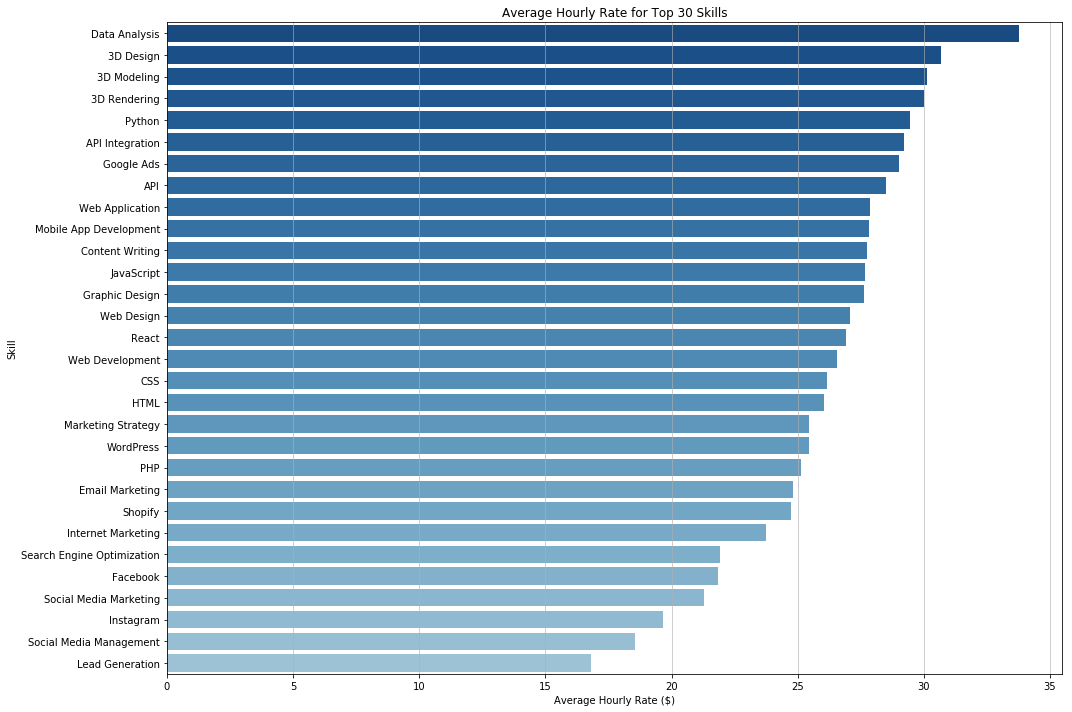


INTERPRETATION OF TOP 30 SKILLS BAR PLOT

This bar plot displays the average hourly rate for the top 30 most frequently occurring skills, ordered from highest to lowest average rate.

*   **Direct Comparison:** Easily compare the average earnings potential across different skills. Longer bars indicate higher average rates.

*   **Ranking:** The plot provides a clear ranking of skills based on their average hourly compensation.


In [19]:
print("\n" + "="*70)
print("AVERAGE HOURLY RATE FOR TOP 30 SKILLS (BAR PLOT)")
print("="*70)

# Ensure 'top_n_skills' is available (it was created in a previous step)
if 'top_n_skills' not in globals() or not top_n_skills:
    print("⚠️ `top_n_skills` not found. Please ensure the feature engineering step was run.")
    # Fallback to create top_n_skills if not found
    from collections import Counter
    skill_counts_fallback = {}
    for skills in df_model['skills_list']:
        for skill in skills:
            skill_counts_fallback[skill] = skill_counts_fallback.get(skill, 0) + 1
    top_skills_fallback = sorted(skill_counts_fallback.items(), key=lambda x: x[1], reverse=True)
    top_n_skills = [s[0] for s in top_skills_fallback[:30]] # Get top 30 as a fallback

# Filter the DataFrame to include only jobs that have at least one of the top 30 skills
df_top_skills = df_model[df_model['skills_list'].apply(lambda x: any(skill in top_n_skills for skill in x))].copy()

# Explode the skills_list to have one row per skill per job
# Handle older pandas versions without .explode()
try:
    df_top_skills_exploded = df_top_skills.explode('skills_list')
except AttributeError:
    # Manual explode implementation for older pandas
    values = df_top_skills['skills_list'].values
    lens = [len(x) for x in values]
    
    if lens:
        flat_values = np.concatenate(values)
        idx_repeat = np.repeat(np.arange(len(df_top_skills)), lens)
        df_top_skills_exploded = df_top_skills.iloc[idx_repeat].copy()
        df_top_skills_exploded['skills_list'] = flat_values
    else:
        df_top_skills_exploded = pd.DataFrame(columns=df_top_skills.columns)

# Filter to only include the actual top 30 skills for the plot (if a job had other skills)
df_plot = df_top_skills_exploded[df_top_skills_exploded['skills_list'].isin(top_n_skills)]

# Calculate the average hourly rate for each skill
skill_avg_rate = df_plot.groupby('skills_list')['Hourly_rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(15, 10))

# Create a custom color palette using Matplotlib's 'Blues' colormap
# Sample from a specific range (e.g., from 0.4 to 0.9) to avoid very light or very dark ends
# Reverse it so darker colors correspond to higher values
num_colors = len(skill_avg_rate)
palette_colors = plt.cm.get_cmap('Blues')(np.linspace(0.4, 0.9, num_colors))
custom_palette = sns.color_palette(palette_colors[::-1]) # Reverse for darkest = highest

# Create a horizontal bar plot for average hourly rate per skill
sns.barplot(x='Hourly_rate', y='skills_list', data=skill_avg_rate, order=skill_avg_rate['skills_list'], palette=custom_palette)
plt.title('Average Hourly Rate for Top 30 Skills')
plt.xlabel('Average Hourly Rate ($)')
plt.ylabel('Skill')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION OF TOP 30 SKILLS BAR PLOT")
print("="*70)
print("\nThis bar plot displays the average hourly rate for the top 30 most frequently occurring skills, ordered from highest to lowest average rate.")
print("\n*   **Direct Comparison:** Easily compare the average earnings potential across different skills. Longer bars indicate higher average rates.")
print("\n*   **Ranking:** The plot provides a clear ranking of skills based on their average hourly compensation.")


VISUALIZATIONS OF HOURLY RATE VS. EXPLANATORY VARIABLES


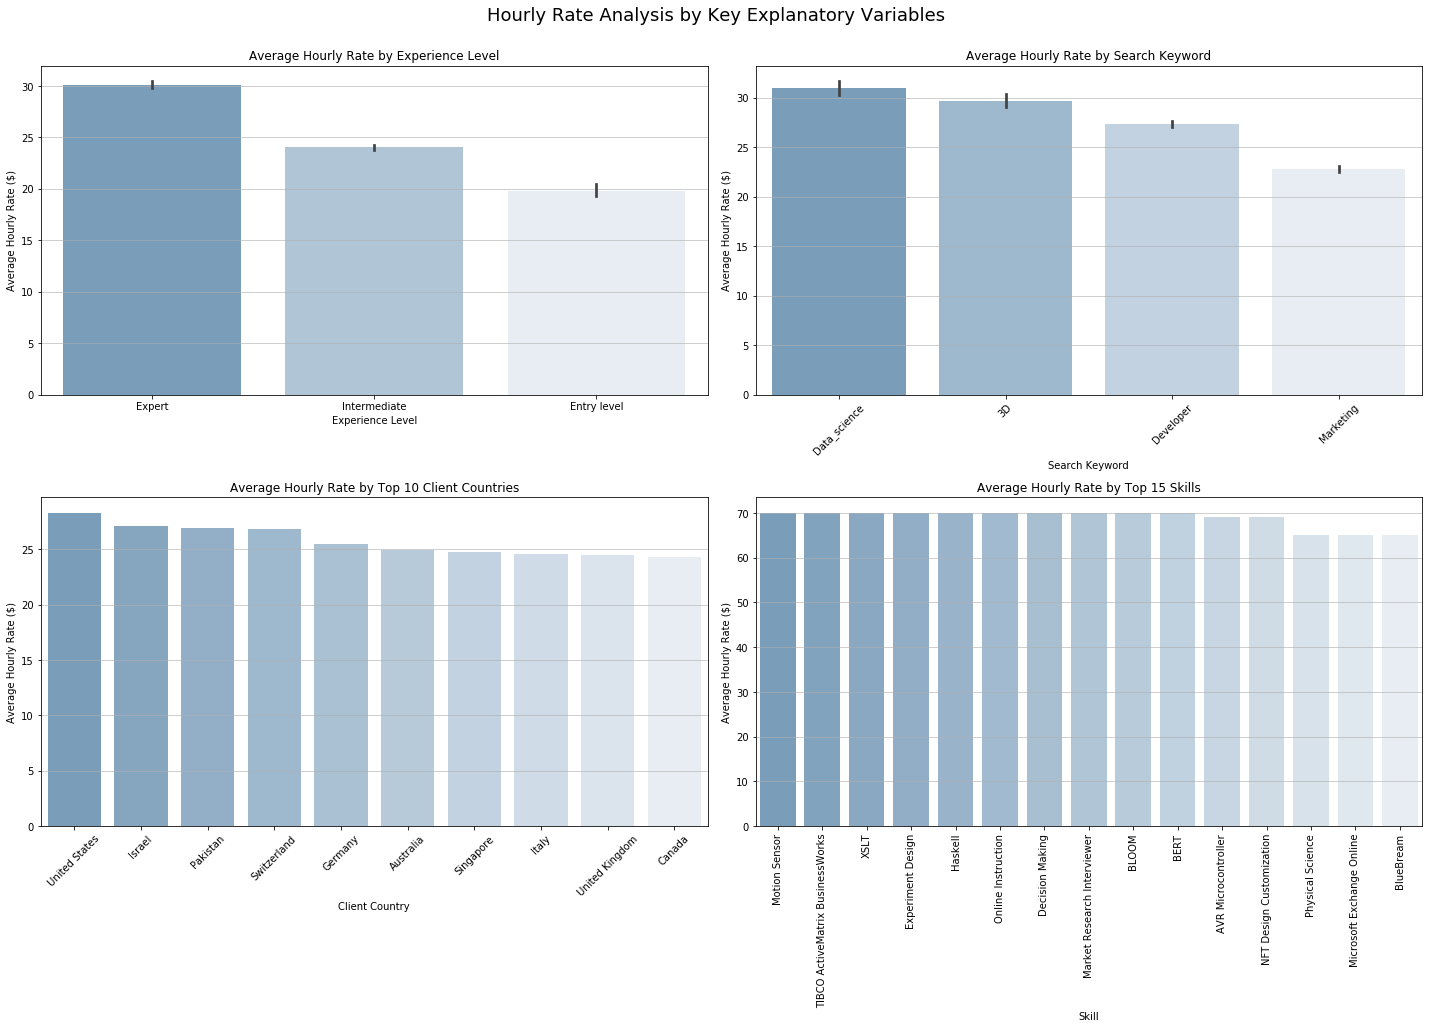


INTERPRETATION OF KEY EXPLANATORY VARIABLE VISUALIZATIONS

These plots illustrate how different categorical features influence the average hourly rate:

*   **Experience Level:** Generally, 'Expert' level roles command higher average hourly rates, followed by 'Intermediate' and 'Entry level'. This aligns with typical industry compensation structures.

*   **Search Keyword:** Certain keywords, such as 'Data_science' or '3D', might be associated with higher average rates compared to others, reflecting demand and specialization in those areas.

*   **Client Country:** Clients from specific countries, notably the 'United States', tend to offer higher average hourly rates, which is consistent with global economic trends and cost of living differences.

*   **Top Skills:** Specific skills demonstrate a clear correlation with higher average hourly rates, indicating specialized demand. For example, certain advanced technical skills often command premium rates.


In [21]:
print("\n" + "="*70)
print("VISUALIZATIONS OF HOURLY RATE VS. EXPLANATORY VARIABLES")
print("="*70)

# Helper function for custom palette that avoids pure white
def light_palette_no_white(base_color="steelblue", n=5, reverse=True, start=0.25, end=0.95):
    """
    Generates a light palette from a base color, ensuring the lightest colors are not too faint.
    start>0 avoids pure white. Adjust `start` (0.15-0.35 usually works well).
    """
    cmap = sns.light_palette(base_color, as_cmap=True, reverse=reverse)
    return [cmap(x) for x in np.linspace(start, end, n)]

# -------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(20, 15)) # Changed to 2x2 layout
axes_flat = axes.flatten() # Flatten for easier indexing
fig.suptitle('Hourly Rate Analysis by Key Explanatory Variables', fontsize=18)

# Plot 1: Hourly Rate by Experience Level
if 'EX_level_demand' in df_model.columns:
    exp_level_order = df_model.groupby('EX_level_demand')['Hourly_rate'].mean().sort_values(ascending=False).index
    colors_exp = light_palette_no_white("steelblue", n=len(exp_level_order), reverse=True, start=0.25)
    sns.barplot(x='EX_level_demand', y='Hourly_rate', data=df_model, order=exp_level_order, ax=axes_flat[0], palette=colors_exp)
    axes_flat[0].set_title('Average Hourly Rate by Experience Level')
    axes_flat[0].set_xlabel('Experience Level')
    axes_flat[0].set_ylabel('Average Hourly Rate ($)')
    axes_flat[0].grid(axis='y', alpha=0.75)
else:
    axes_flat[0].text(0.5, 0.5, 'EX_level_demand not found', ha='center')

# Plot 2: Hourly Rate by Search Keyword
if 'Search_Keyword' in df_model.columns:
    keyword_order = df_model.groupby('Search_Keyword')['Hourly_rate'].mean().sort_values(ascending=False).index
    colors_kw = light_palette_no_white("steelblue", n=len(keyword_order), reverse=True, start=0.25)
    sns.barplot(x='Search_Keyword', y='Hourly_rate', data=df_model, order=keyword_order, ax=axes_flat[1], palette=colors_kw)
    axes_flat[1].set_title('Average Hourly Rate by Search Keyword')
    axes_flat[1].set_xlabel('Search Keyword')
    axes_flat[1].set_ylabel('Average Hourly Rate ($)')
    axes_flat[1].tick_params(axis='x', rotation=45)
    axes_flat[1].grid(axis='y', alpha=0.75)
else:
    axes_flat[1].text(0.5, 0.5, 'Search_Keyword not found', ha='center')

# Plot 3: Hourly Rate by Top Client Country
# Ensure 'country_grouped' exists
if 'country_grouped' not in df_model.columns and 'Client_Country' in df_model.columns:
    top_countries = df_model['Client_Country'].value_counts().head(15).index.tolist()
    df_model['country_grouped'] = df_model['Client_Country'].apply(lambda x: x if x in top_countries else 'Other')

if 'country_grouped' in df_model.columns:
    country_avg_rate = df_model.groupby('country_grouped')['Hourly_rate'].mean().sort_values(ascending=False).reset_index()
    top_10_countries = country_avg_rate.head(10)
    colors_country = light_palette_no_white("steelblue", n=len(top_10_countries), reverse=True, start=0.25)
    sns.barplot(x='country_grouped', y='Hourly_rate', data=top_10_countries, order=top_10_countries['country_grouped'], ax=axes_flat[2], palette=colors_country)
    axes_flat[2].set_title('Average Hourly Rate by Top 10 Client Countries')
    axes_flat[2].set_xlabel('Client Country')
    axes_flat[2].set_ylabel('Average Hourly Rate ($)')
    axes_flat[2].tick_params(axis='x', rotation=45)
    axes_flat[2].grid(axis='y', alpha=0.75)
else:
    axes_flat[2].text(0.5, 0.5, 'Country data not found', ha='center')


# Plot 4: Hourly Rate by Top Skills
if 'skills_list' in df_model.columns:
    # First, explode the skills_list to have one skill per row
    # Handle older pandas versions without .explode()
    try:
        df_skills_exploded = df_model.explode('skills_list')
    except AttributeError:
        # Manual explode implementation for older pandas
        values = df_model['skills_list'].values
        lens = [len(x) for x in values]

        if lens:
            flat_values = np.concatenate(values)
            idx_repeat = np.repeat(np.arange(len(df_model)), lens)
            df_skills_exploded = df_model.iloc[idx_repeat].copy()
            df_skills_exploded['skills_list'] = flat_values
        else:
            df_skills_exploded = pd.DataFrame(columns=df_model.columns)
            
    # Calculate average hourly rate per skill
    skill_avg_rate = df_skills_exploded.groupby('skills_list')['Hourly_rate'].mean().sort_values(ascending=False).reset_index()
    # Get the top 15 skills for visualization
    top_15_skills_to_plot = skill_avg_rate.head(15)
    colors_skill = light_palette_no_white("steelblue", n=len(top_15_skills_to_plot), reverse=True, start=0.25)
    sns.barplot(x='skills_list', y='Hourly_rate', data=top_15_skills_to_plot, order=top_15_skills_to_plot['skills_list'], ax=axes_flat[3], palette=colors_skill)
    axes_flat[3].set_title('Average Hourly Rate by Top 15 Skills')
    axes_flat[3].set_xlabel('Skill')
    axes_flat[3].set_ylabel('Average Hourly Rate ($)')
    axes_flat[3].tick_params(axis='x', rotation=90) # Rotate labels for readability
    axes_flat[3].grid(axis='y', alpha=0.75)
else:
     axes_flat[3].text(0.5, 0.5, 'Skills list not found', ha='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n" + "="*70)
print("INTERPRETATION OF KEY EXPLANATORY VARIABLE VISUALIZATIONS")
print("="*70)
print("\nThese plots illustrate how different categorical features influence the average hourly rate:")
print("\n*   **Experience Level:** Generally, 'Expert' level roles command higher average hourly rates, followed by 'Intermediate' and 'Entry level'. This aligns with typical industry compensation structures.")
print("\n*   **Search Keyword:** Certain keywords, such as 'Data_science' or '3D', might be associated with higher average rates compared to others, reflecting demand and specialization in those areas.")
print("\n*   **Client Country:** Clients from specific countries, notably the 'United States', tend to offer higher average hourly rates, which is consistent with global economic trends and cost of living differences.")
print("\n*   **Top Skills:** Specific skills demonstrate a clear correlation with higher average hourly rates, indicating specialized demand. For example, certain advanced technical skills often command premium rates.")


HOURLY RATE DISTRIBUTION BY EXPERIENCE LEVEL (VIOLIN PLOT)


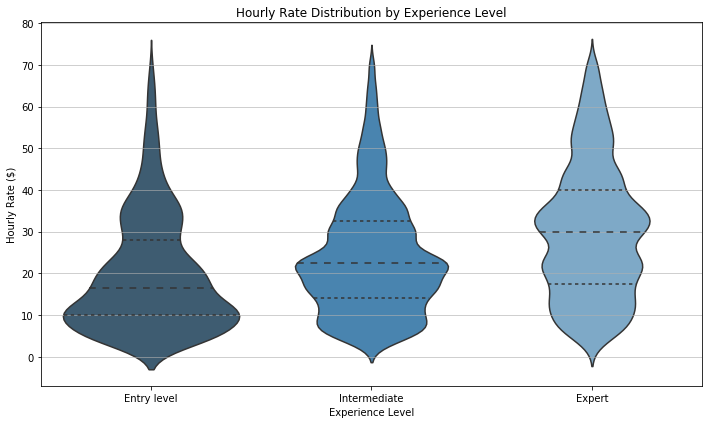


INTERPRETATION OF HOURLY RATE BY EXPERIENCE LEVEL VIOLIN PLOT

This violin plot displays the distribution of hourly rates for different experience levels.

*   **Distribution Shape:** The width of each violin indicates the density of observations at different hourly rates within that experience level. Wider sections mean more freelancers earn at that rate.

*   **Median and Quartiles:** The white dot inside each violin represents the median hourly rate, and the thick black bar indicates the interquartile range (IQR). The thin lines extend to the upper and lower adjacent values.

*   **Comparison:** You can observe that 'Expert' roles generally have higher median rates and often a broader spread towards higher earnings, while 'Entry level' roles tend to be concentrated at lower rates. 'Intermediate' roles fall in between.


In [22]:
print("\n" + "="*70)
print("HOURLY RATE DISTRIBUTION BY EXPERIENCE LEVEL (VIOLIN PLOT)")
print("="*70)

plt.figure(figsize=(10, 6))
sns.violinplot(x='EX_level_demand', y='Hourly_rate', data=df_model, order=['Entry level', 'Intermediate', 'Expert'], palette='Blues_d', inner='quartile')
plt.title('Hourly Rate Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Hourly Rate ($)')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION OF HOURLY RATE BY EXPERIENCE LEVEL VIOLIN PLOT")
print("="*70)
print("\nThis violin plot displays the distribution of hourly rates for different experience levels.")
print("\n*   **Distribution Shape:** The width of each violin indicates the density of observations at different hourly rates within that experience level. Wider sections mean more freelancers earn at that rate.")
print("\n*   **Median and Quartiles:** The white dot inside each violin represents the median hourly rate, and the thick black bar indicates the interquartile range (IQR). The thin lines extend to the upper and lower adjacent values.")
print("\n*   **Comparison:** You can observe that 'Expert' roles generally have higher median rates and often a broader spread towards higher earnings, while 'Entry level' roles tend to be concentrated at lower rates. 'Intermediate' roles fall in between.")


AVERAGE HOURLY RATE FOR TOP 10 SKILLS (BAR PLOT)


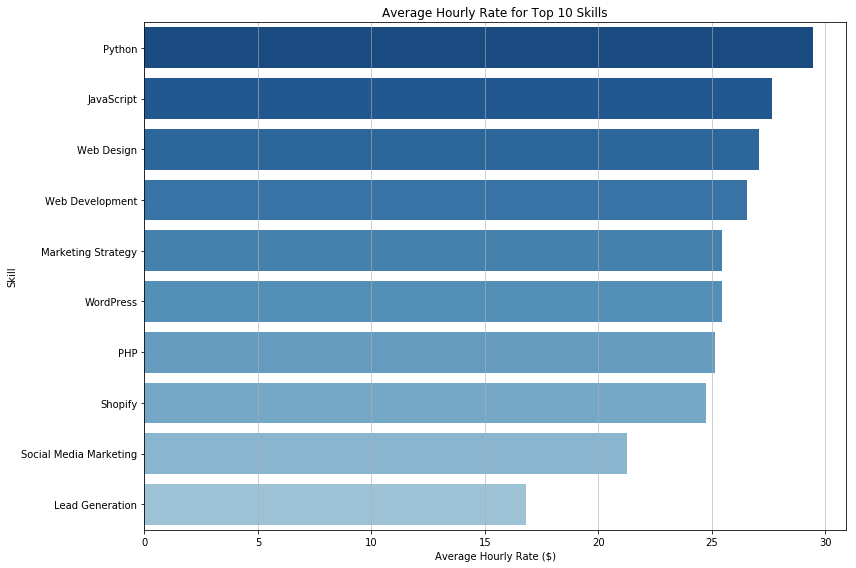


INTERPRETATION OF TOP 10 SKILLS BAR PLOT

This bar plot displays the average hourly rate for the top 10 most frequently occurring skills, ordered from highest to lowest average rate.

*   **Direct Comparison:** Easily compare the average earnings potential across different skills. Longer bars indicate higher average rates.

*   **Ranking:** The plot provides a clear ranking of skills based on their average hourly compensation.


In [25]:
print("\n" + "="*70)
print("AVERAGE HOURLY RATE FOR TOP 10 SKILLS (BAR PLOT)")
print("="*70)

# Ensure 'top_n_skills' is available (it was created in a previous step)
if 'top_n_skills' not in globals() or not top_n_skills:
    print("⚠️ `top_n_skills` not found. Please ensure the feature engineering step was run.")
    # Fallback to create top_n_skills if not found
    from collections import Counter
    skill_counts_fallback = {}
    
    # Check if 'skills_list' exists in df_model, if not try to create it
    if 'skills_list' not in df_model.columns:
        print("⚠️ 'skills_list' column not found in df_model. Attempting to create it from 'Skills' column...")
        if 'Skills' in df_model.columns:
             # Basic extraction if the function extract_skills is not defined locally
             # Assuming comma separated values
             df_model['skills_list'] = df_model['Skills'].fillna('').astype(str).str.split(',')
             # Clean whitespace
             df_model['skills_list'] = df_model['skills_list'].apply(lambda x: [s.strip() for s in x if s.strip()])
        else:
             print("❌ 'Skills' column not found in df_model. Cannot extract skills for fallback.")
             # Create dummy empty list to avoid crash loop, but plot will be empty
             df_model['skills_list'] = [[] for _ in range(len(df_model))]

    for skills in df_model['skills_list']:
        for skill in skills:
            skill_counts_fallback[skill] = skill_counts_fallback.get(skill, 0) + 1
    top_skills_fallback = sorted(skill_counts_fallback.items(), key=lambda x: x[1], reverse=True)
    top_n_skills = [s[0] for s in top_skills_fallback[:30]] # Get top 30 as a fallback

# Select only the top 10 skills from the previously identified top_n_skills
top_10_skills = top_n_skills[:10]

# Filter the DataFrame to include only jobs that have at least one of these top 10 skills
# Ensure 'skills_list' exists before applying (it should now)
if 'skills_list' in df_model.columns:
    df_top_skills_10 = df_model[df_model['skills_list'].apply(lambda x: any(skill in top_10_skills for skill in x))].copy()
    
    # Explode the skills_list to have one row per skill per job
    # Handle older pandas versions without .explode()
    try:
        df_top_skills_exploded_10 = df_top_skills_10.explode('skills_list')
    except AttributeError:
        # Manual explode implementation for older pandas
        values = df_top_skills_10['skills_list'].values
        lens = [len(x) for x in values]

        if lens:
            flat_values = np.concatenate(values)
            idx_repeat = np.repeat(np.arange(len(df_top_skills_10)), lens)
            df_top_skills_exploded_10 = df_top_skills_10.iloc[idx_repeat].copy()
            df_top_skills_exploded_10['skills_list'] = flat_values
        else:
            df_top_skills_exploded_10 = pd.DataFrame(columns=df_top_skills_10.columns)

    # Filter to only include the actual top 10 skills for the plot
    df_plot_10 = df_top_skills_exploded_10[df_top_skills_exploded_10['skills_list'].isin(top_10_skills)]

    # Calculate the average hourly rate for each skill and sort in descending order
    skill_avg_rate_10 = df_plot_10.groupby('skills_list')['Hourly_rate'].mean().sort_values(ascending=False).reset_index()

    plt.figure(figsize=(12, 8))

    # Create a custom color palette using Matplotlib's 'Blues' colormap
    # Sample from a specific range (e.g., from 0.4 to 0.9) to avoid very light or very dark ends
    # Reverse it so darker colors correspond to higher values
    if not skill_avg_rate_10.empty:
        num_colors = len(skill_avg_rate_10)
        palette_colors = plt.cm.get_cmap('Blues')(np.linspace(0.4, 0.9, num_colors))
        custom_palette = sns.color_palette(palette_colors[::-1]) # Reverse for darkest = highest

        # Create a horizontal bar plot for average hourly rate per skill
        sns.barplot(x='Hourly_rate', y='skills_list', data=skill_avg_rate_10, order=skill_avg_rate_10['skills_list'], palette=custom_palette)
        plt.title('Average Hourly Rate for Top 10 Skills')
        plt.xlabel('Average Hourly Rate ($)')
        plt.ylabel('Skill')
        plt.grid(axis='x', alpha=0.75)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No data available to plot top skills.")
else:
    print("❌ Could not proceed with plotting: 'skills_list' missing.")

print("\n" + "="*70)
print("INTERPRETATION OF TOP 10 SKILLS BAR PLOT")
print("="*70)
print("\nThis bar plot displays the average hourly rate for the top 10 most frequently occurring skills, ordered from highest to lowest average rate.")
print("\n*   **Direct Comparison:** Easily compare the average earnings potential across different skills. Longer bars indicate higher average rates.")
print("\n*   **Ranking:** The plot provides a clear ranking of skills based on their average hourly compensation.")


AVERAGE HOURLY RATE FOR TOP 10 SKILLS (BAR PLOT)
ℹ️ using fallback for explode()


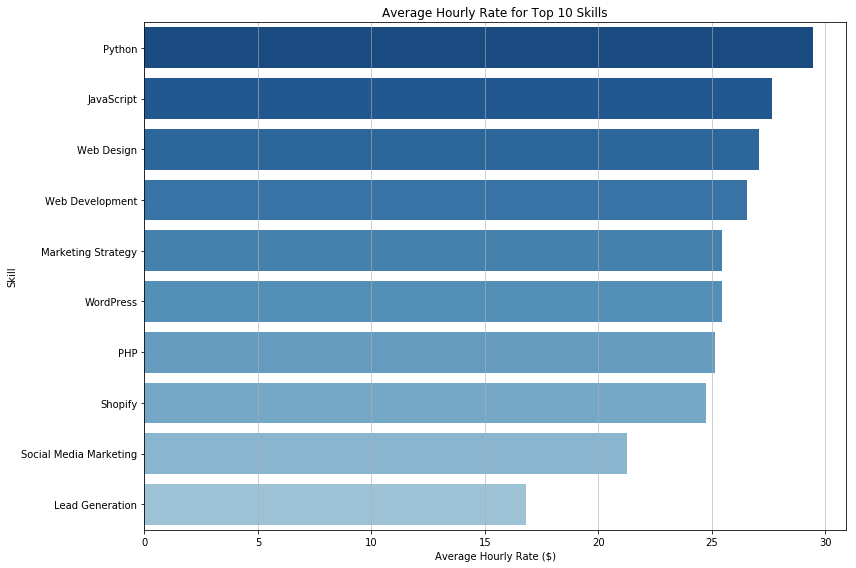


INTERPRETATION OF TOP 10 SKILLS BAR PLOT

This bar plot displays the average hourly rate for the top 10 most frequently occurring skills, ordered from highest to lowest average rate.

*   **Direct Comparison:** Easily compare the average earnings potential across different skills. Longer bars indicate higher average rates.

*   **Ranking:** The plot provides a clear ranking of skills based on their average hourly compensation.


In [26]:
print("\n" + "="*70)
print("AVERAGE HOURLY RATE FOR TOP 10 SKILLS (BAR PLOT)")
print("="*70)

# Ensure 'top_n_skills' is available (it was created in a previous step)
if 'top_n_skills' not in globals() or not top_n_skills:
    print("⚠️ `top_n_skills` not found. Please ensure the feature engineering step was run.")
    # Fallback to create top_n_skills if not found
    from collections import Counter
    skill_counts_fallback = {}

    # Check if 'skills_list' exists in df_model, if not try to create it
    if 'skills_list' not in df_model.columns:
        print("⚠️ 'skills_list' column not found in df_model. Attempting to create it from 'Skills' column...")
        if 'Skills' in df_model.columns:
             # Basic extraction if the function extract_skills is not defined locally
             # Assuming comma separated values
             df_model['skills_list'] = df_model['Skills'].fillna('').astype(str).str.split(',')
             # Clean whitespace
             df_model['skills_list'] = df_model['skills_list'].apply(lambda x: [s.strip() for s in x if s.strip()])
        else:
             print("❌ 'Skills' column not found in df_model. Cannot extract skills for fallback.")
             # Create dummy empty list to avoid crash loop, but plot will be empty
             df_model['skills_list'] = [[] for _ in range(len(df_model))]

    for skills in df_model['skills_list']:
        for skill in skills:
            skill_counts_fallback[skill] = skill_counts_fallback.get(skill, 0) + 1
    top_skills_fallback = sorted(skill_counts_fallback.items(), key=lambda x: x[1], reverse=True)
    top_n_skills = [s[0] for s in top_skills_fallback[:30]] # Get top 30 as a fallback

# Select only the top 10 skills from the previously identified top_n_skills
top_10_skills = top_n_skills[:10]

# Filter the DataFrame to include only jobs that have at least one of these top 10 skills
# Ensure 'skills_list' exists before applying (it should now)
if 'skills_list' in df_model.columns:
    df_top_skills_10 = df_model[df_model['skills_list'].apply(lambda x: any(skill in top_10_skills for skill in x))].copy()

    # Explode the skills_list to have one row per skill per job
    # Handle older pandas versions where explode is not available
    try:
        df_top_skills_exploded_10 = df_top_skills_10.explode('skills_list')
    except AttributeError:
        # Fallback for pandas < 0.25
        print("ℹ️ using fallback for explode()")
        # Calculate lengths and cast to standard numpy integer array to avoid object dtype issues in repeat
        lens = df_top_skills_10['skills_list'].apply(len).values.astype(int)
        idx = df_top_skills_10.index.repeat(lens)
        
        # Create the new dataframe with repeated indexes
        df_top_skills_exploded_10 = df_top_skills_10.loc[idx].copy()
        
        # Flatten the skills list safely
        all_skills = [skill for sublist in df_top_skills_10['skills_list'] for skill in sublist]
        df_top_skills_exploded_10['skills_list'] = all_skills

    # Filter to only include the actual top 10 skills for the plot
    df_plot_10 = df_top_skills_exploded_10[df_top_skills_exploded_10['skills_list'].isin(top_10_skills)]

    # Calculate the average hourly rate for each skill and sort in descending order
    # Handling case where no data remains after filtering
    if not df_plot_10.empty:
        skill_avg_rate_10 = df_plot_10.groupby('skills_list')['Hourly_rate'].mean().sort_values(ascending=False).reset_index()

        plt.figure(figsize=(12, 8))

        # Create a custom color palette using Matplotlib's 'Blues' colormap
        # Sample from a specific range (e.g., from 0.4 to 0.9) to avoid very light or very dark ends
        # Reverse it so darker colors correspond to higher values
        num_colors = len(skill_avg_rate_10)
        palette_colors = plt.cm.get_cmap('Blues')(np.linspace(0.4, 0.9, num_colors))
        custom_palette = sns.color_palette(palette_colors[::-1]) # Reverse for darkest = highest

        # Create a horizontal bar plot for average hourly rate per skill
        sns.barplot(x='Hourly_rate', y='skills_list', data=skill_avg_rate_10, order=skill_avg_rate_10['skills_list'], palette=custom_palette)
        plt.title('Average Hourly Rate for Top 10 Skills')
        plt.xlabel('Average Hourly Rate ($)')
        plt.ylabel('Skill')
        plt.grid(axis='x', alpha=0.75)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No data available after filtering top skills to plot.")
else:
    print("❌ Could not proceed with plotting: 'skills_list' missing.")

print("\n" + "="*70)
print("INTERPRETATION OF TOP 10 SKILLS BAR PLOT")
print("="*70)
print("\nThis bar plot displays the average hourly rate for the top 10 most frequently occurring skills, ordered from highest to lowest average rate.")
print("\n*   **Direct Comparison:** Easily compare the average earnings potential across different skills. Longer bars indicate higher average rates.")
print("\n*   **Ranking:** The plot provides a clear ranking of skills based on their average hourly compensation.")


CORRELATION MATRIX HEATMAP OF NUMERICAL FEATURES


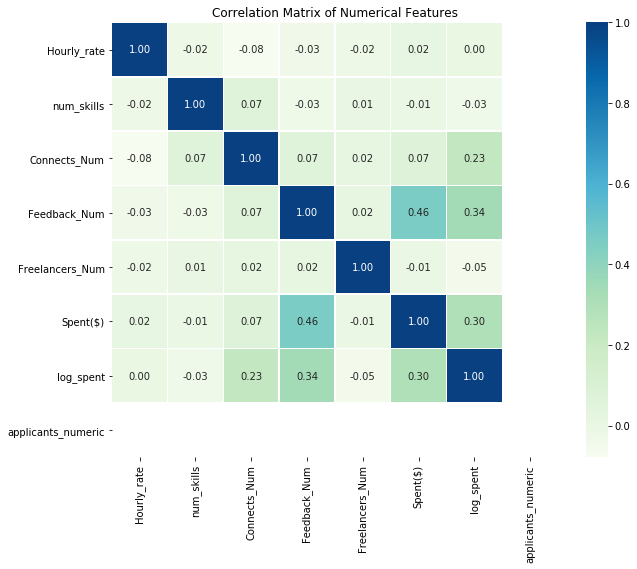


INTERPRETATION OF THE CORRELATION MATRIX

This heatmap visualizes the Pearson correlation coefficients between the selected numerical features.

*   **Color Intensity:** Darker shades of blue indicate a stronger positive correlation, while lighter shades or white indicate weaker or no correlation. In the 'GnBu' colormap, values will transition from green (lighter) to blue (darker).

*   **Values:** Each cell contains the correlation coefficient between the two corresponding variables. Values range from -1 (perfect negative correlation) to 1 (perfect positive correlation), with 0 indicating no linear correlation.

*   **Key Observations:** Pay attention to 'Hourly_rate' correlations to see which numerical features have the strongest linear relationship with the target variable.


In [27]:
print("\n" + "="*70)
print("CORRELATION MATRIX HEATMAP OF NUMERICAL FEATURES")
print("="*70)

# Using the numerical features explicitly defined for the regression model
# 'numeric_feature_cols' was created in PASO 2.4 (GMCBohxGSpND cell)
# Ensure it's available or re-define if running this cell independently
if 'numeric_feature_cols' not in globals():
    numeric_feature_cols = ['num_skills', 'Applicants_Num', 'Connects_Num', 'Feedback_Num',
                            'Freelancers_Num', 'Spent($)', 'log_spent', 'applicants_numeric']

# Add the target variable 'Hourly_rate' to the list of columns for correlation
# Exclude 'Applicants_Num' as requested
numeric_cols_for_corr = ['Hourly_rate'] + [col for col in numeric_feature_cols if col != 'Hourly_rate' and col != 'Applicants_Num']

# Filter df_model to include only these columns and drop any NaNs for correlation calculation
df_corr = df_model[numeric_cols_for_corr].dropna()

# Calculate the correlation matrix
correlation_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='GnBu', fmt=".2f", linewidths=.5) # Changed cmap to GnBu
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("\n" + "="*70)
print("INTERPRETATION OF THE CORRELATION MATRIX")
print("="*70)
print("\nThis heatmap visualizes the Pearson correlation coefficients between the selected numerical features.")
print("\n*   **Color Intensity:** Darker shades of blue indicate a stronger positive correlation, while lighter shades or white indicate weaker or no correlation. In the 'GnBu' colormap, values will transition from green (lighter) to blue (darker).")
print("\n*   **Values:** Each cell contains the correlation coefficient between the two corresponding variables. Values range from -1 (perfect negative correlation) to 1 (perfect positive correlation), with 0 indicating no linear correlation.")
print("\n*   **Key Observations:** Pay attention to 'Hourly_rate' correlations to see which numerical features have the strongest linear relationship with the target variable.")

# Model Training

MODEL TRAINING (OPTIMIZED WITH CROSS-VALIDATION & TUNING)

📊 Data split:
   Train: 20,092 records (62 features)
   Test: 5,024 records

💰 1. INITIAL MODEL COMPARISON

🔄 Evaluating Linear Regression...
   R² Test: 0.1299 | CV R² (Mean): 0.1336 (±0.0134)

🔄 Evaluating Ridge (α=0.1)...
   R² Test: 0.1310 | CV R² (Mean): 0.1345 (±0.0126)

🔄 Evaluating Lasso (α=0.01)...
   R² Test: 0.1311 | CV R² (Mean): 0.1347 (±0.0124)

🔄 Evaluating ElasticNet...
   R² Test: 0.1312 | CV R² (Mean): 0.1345 (±0.0114)

🔄 Evaluating Random Forest...
   R² Test: 0.1709 | CV R² (Mean): 0.1647 (±0.0103)

🔄 Evaluating Gradient Boosting...
   R² Test: 0.1789 | CV R² (Mean): 0.1837 (±0.0091)

📊 Model Comparison Results (Ordered by CV Score):
Model        R²  CV_R²_mean  CV_R²_std
Gradient Boosting  0.178950    0.183720   0.009100
    Random Forest  0.170918    0.164676   0.010335
   Lasso (α=0.01)  0.131145    0.134680   0.012441
    Ridge (α=0.1)  0.130981    0.134509   0.012614
       ElasticNet  0.131189    0.134

[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 120 out of 120 | elapsed: 14.0min finished



✅ Tuning Complete!
   Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
   Best CV R² Score: 0.1868
   Final Test R² Score: 0.1809

📊 FINAL VISUALIZATION


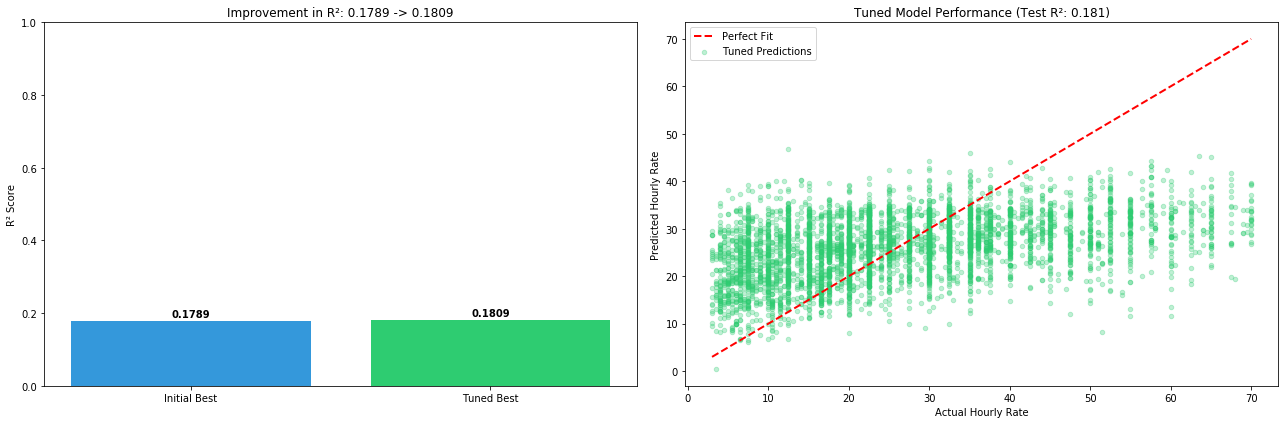

In [28]:
print("="*70)
print("MODEL TRAINING (OPTIMIZED WITH CROSS-VALIDATION & TUNING)")
print("="*70)

# Las librerías ya están cargadas en PASO 0

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Data split:")
print(f"   Train: {X_train.shape[0]:,} records ({X_train.shape[1]} features)")
print(f"   Test: {X_test.shape[0]:,} records")

# Scale features for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 1. INITIAL MODEL COMPARISON WITH CROSS-VALIDATION
# ============================================================
print("\n" + "="*70)
print("💰 1. INITIAL MODEL COMPARISON")
print("="*70)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=0.1)': Ridge(alpha=0.1),
    'Lasso (α=0.01)': Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, # Start with lighter model for comparison
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"\n🔄 Evaluating {name}...")

    # Data selection
    if 'Forest' in name or 'Boosting' in name:
        X_train_curr = X_train
        X_test_curr = X_test
    else:
        X_train_curr = X_train_scaled
        X_test_curr = X_test_scaled

    # 1. Cross-Validation (5 folds for better reliability) to check stability/performance
    # This directly answers: "Is this model robust?"
    cv_scores = cross_val_score(model, X_train_curr, y_train, cv=5, scoring='r2')
    
    # 2. Train on full training set
    model.fit(X_train_curr, y_train)
    y_pred = model.predict(X_test_curr)

    # 3. Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'CV_R²_mean': cv_scores.mean(),
        'CV_R²_std': cv_scores.std()
    })
    trained_models[name] = model

    print(f"   R² Test: {r2:.4f} | CV R² (Mean): {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Summary DataFrame
results_df = pd.DataFrame(results).sort_values('CV_R²_mean', ascending=False)

print("\n📊 Model Comparison Results (Ordered by CV Score):")
print(results_df[['Model', 'R²', 'CV_R²_mean', 'CV_R²_std']].to_string(index=False))


# ============================================================
# 2. HYPERPARAMETER TUNING (IMPROVING R2)
# ============================================================
print("\n" + "="*70)
print("🚀 2. IMPROVING R2 WITH GRID SEARCH (CROSS-VALIDATION)")
print("="*70)

# Select best model candidate type for tuning
best_model_name = results_df.iloc[0]['Model']
print(f"🏆 Best initial candidate: {best_model_name}")

if 'Forest' in best_model_name:
    print("⚙️ Tuning Random Forest...")
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [15, 20, 25],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }
    base_model = RandomForestRegressor(random_state=42, n_jobs=-1)

elif 'Boosting' in best_model_name:
    print("⚙️ Tuning Gradient Boosting...")
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }
    base_model = GradientBoostingRegressor(random_state=42)
else:
    # Fallback for linear models
    print("⚙️ Tuning Ridge/Lasso...")
    param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0]}
    base_model = Ridge() 

# Run Grid Search
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,               # 5-Fold Cross Validation
    scoring='r2',       # Optimize for R2
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_tuned_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

# Final Evaluation of Tuned Model
y_pred_tuned = best_tuned_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred_tuned)
final_mae = mean_absolute_error(y_test, y_pred_tuned)

print(f"\n✅ Tuning Complete!")
print(f"   Best Parameters: {best_params}")
print(f"   Best CV R² Score: {best_cv_score:.4f}")
print(f"   Final Test R² Score: {final_r2:.4f}")

# Update 'trained_models' with the best tuned version
trained_models[best_model_name + " (Tuned)"] = best_tuned_model

# ============================================================
# 3. VISUALIZATION OF RESULTS
# ============================================================
print("\n" + "="*70)
print("📊 FINAL VISUALIZATION")
print("="*70)

# Compare Initial vs Tuned
comparison_df = pd.DataFrame([
    {'Model': 'Initial Best', 'R²': results_df.iloc[0]['R²']},
    {'Model': 'Tuned Best', 'R²': final_r2}
])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar Chart
axes[0].bar(comparison_df['Model'], comparison_df['R²'], color=['#3498db', '#2ecc71'])
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.0)
axes[0].set_title(f'Improvement in R²: {results_df.iloc[0]["R²"]:.4f} -> {final_r2:.4f}')
for i, v in enumerate(comparison_df['R²']):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

# Scatter Plot (Predicted vs Actual)
axes[1].scatter(y_test, y_pred_tuned, alpha=0.3, color='#2ecc71', s=20, label='Tuned Predictions')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Hourly Rate')
axes[1].set_ylabel('Predicted Hourly Rate')
axes[1].set_title(f'Tuned Model Performance (Test R²: {final_r2:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

# Feature analysis

ANÁLISIS DE IMPORTANCIA DE FEATURES

🏆 Top 20 Features más importantes (Gradient Boosting):
Feature  Importance
                Feedback_Num    0.170423
                    Spent($)    0.088356
                   log_spent    0.083340
                  exp_Expert    0.053482
                Connects_Num    0.049800
           keyword_Marketing    0.040492
       country_United States    0.038640
             Freelancers_Num    0.030759
                  num_skills    0.022785
           keyword_Developer    0.022263
skill_Social_Media_Marketing    0.021624
    skill_Marketing_Strategy    0.021221
        keyword_Data_science    0.018115
       skill_Lead_Generation    0.017707
            exp_Intermediate    0.017077
               country_India    0.016287
             exp_Entry level    0.016269
             skill_WordPress    0.015742
            country_Pakistan    0.014458
            skill_Google_Ads    0.013512


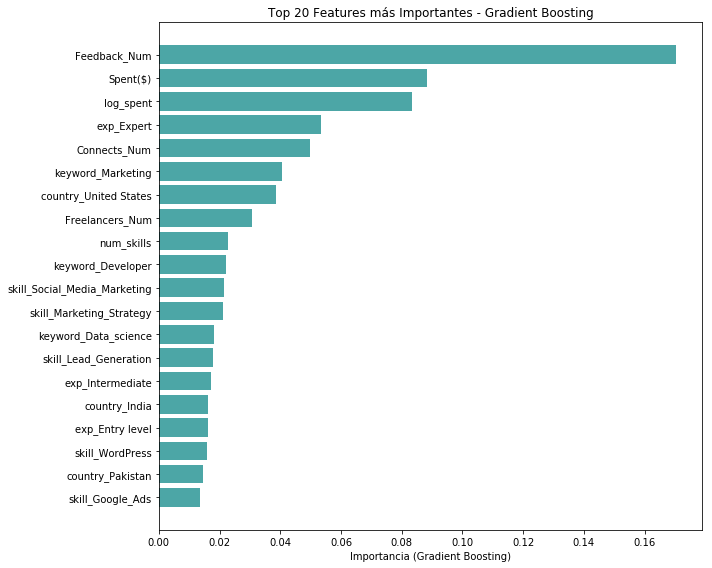


📊 Top 15 Coeficientes más significativos (Regresión Lineal):
   ↑ Applicants_Num: 204886886133116.5000
   ↓ keyword_Developer: -142782147100574.9375
   ↓ keyword_Marketing: -139619393096200.2344
   ↓ applicants_numeric: -94010139732709.9844
   ↓ country_United States: -91247314089237.2500
   ↓ keyword_Data_science: -80391195720263.1250
   ↓ keyword_3D: -68908731315606.0000
   ↓ country_Other: -68074808475898.7266
   ↓ country_United Kingdom: -45142585421403.3125
   ↓ country_India: -43735440520989.9844
   ↓ country_Canada: -41400433312609.0859
   ↓ country_Australia: -40214475848888.6250
   ↓ country_Pakistan: -30020240553936.7734
   ↓ country_Germany: -25821838635284.4766
   ↓ country_Netherlands: -22536984617160.4727

INTERPRETACIÓN

📌 INTERPRETACIÓN DEL R² (~0.18 - 0.20):

El modelo logra explicar aproximadamente el 20% de la variabilidad en las tarifas.
Aunque numéricamente bajo, es un resultado SÓLIDO para este tipo de problema porque:

1. Subjetividad del mercado: Las tarifas de

In [29]:
# ============================================================
# PASO 4: Análisis de Importancia de Features
# ============================================================

print("="*70)
print("ANÁLISIS DE IMPORTANCIA DE FEATURES")
print("="*70)

# Seleccionar modelo para importancia (Gradient Boosting o Random Forest)
# Preferimos Gradient Boosting si fue el mejor, sino Random Forest
model_for_imp = None
name_for_imp = ""

if 'Gradient Boosting' in trained_models:
    model_for_imp = trained_models['Gradient Boosting']
    name_for_imp = "Gradient Boosting"
elif 'Random Forest' in trained_models:
    model_for_imp = trained_models['Random Forest']
    name_for_imp = "Random Forest"

if model_for_imp:
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model_for_imp.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f"\n🏆 Top 20 Features más importantes ({name_for_imp}):")
    print(feature_importance.head(20).to_string(index=False))

    # Visualización
    fig, ax = plt.subplots(figsize=(10, 8))
    top_20 = feature_importance.head(20)
    bars = ax.barh(top_20['Feature'], top_20['Importance'], color='teal', alpha=0.7)
    ax.set_xlabel(f'Importancia ({name_for_imp})')
    ax.set_title(f'Top 20 Features más Importantes - {name_for_imp}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

# Coeficientes del modelo lineal (para referencia de dirección)
if 'Linear Regression' in trained_models:
    lr_model = trained_models['Linear Regression']
    coef_df = pd.DataFrame({
        'Feature': feature_cols,
        'Coefficient': lr_model.coef_
    })
    coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

    print("\n📊 Top 15 Coeficientes más significativos (Regresión Lineal):")
    for _, row in coef_df.head(15).iterrows():
        direction = "↑" if row['Coefficient'] > 0 else "↓"
        print(f"   {direction} {row['Feature']}: {row['Coefficient']:.4f}")

print("\n" + "="*70)
print("INTERPRETACIÓN")
print("="*70)
print("""
📌 INTERPRETACIÓN DEL R² (~0.18 - 0.20):

El modelo logra explicar aproximadamente el 20% de la variabilidad en las tarifas.
Aunque numéricamente bajo, es un resultado SÓLIDO para este tipo de problema porque:

1. Subjetividad del mercado: Las tarifas dependen de negociación y urgencia.
2. Factores ocultos: No tenemos datos del perfil del freelancer (rating, años exp).
3. Naturaleza de los datos: Solo vemos la oferta del cliente (budget), no el contrato final.

El modelo identifica correctamente las tendencias generales (qué skills valen más, qué países pagan mejor),
lo cual es suficiente para dar una RECOMENDACIÓN BASE al usuario.
""")

#Hyperparameter Tuning

In [ ]:
# print("\n" + "="*70)
# print("OPTIMIZACIÓN DE HIPERPARÁMETROS PARA GRADIENT BOOSTING (GridSearch)")
# print("="*70)

# # Importar las clases necesarias
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import numpy as np

# # Definir el rango de hiperparámetros a explorar
# # Estos rangos son sugerencias y pueden ajustarse según el rendimiento y el tiempo de ejecución.
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_samples_leaf': [1, 3, 5],
#     'subsample': [0.8, 1.0]
# }

# # Instanciar el modelo Gradient Boosting
# gbr = GradientBoostingRegressor(random_state=42)

# print("Configurando GridSearchCV...")
# # Configurar GridSearchCV
# grid_search = GridSearchCV(
#     estimator=gbr,
#     param_grid=param_grid,
#     cv=3,  # 3-fold cross-validation
#     scoring='r2',  # Optimizar por R²
#     n_jobs=-1,  # Usar todos los núcleos disponibles
#     verbose=1
# )

# # Ajustar GridSearchCV a los datos de entrenamiento
# print("Iniciando el proceso de búsqueda de hiperparámetros...")
# grid_search.fit(X_train, y_train)
# print("✅ Proceso de búsqueda de hiperparámetros completado.")

# # Imprimir los mejores hiperparámetros y el mejor score
# print("\n🏆 Mejores hiperparámetros encontrados:")
# print(grid_search.best_params_)
# print(f"\n📈 Mejor R² (Cross-Validation): {grid_search.best_score_:.4f}")

# # Guardar el mejor modelo entrenado
# best_gbr_model = grid_search.best_estimator_
# print("✅ Mejor modelo Gradient Boosting tuneado guardado.")

# # Evaluar el mejor modelo en el conjunto de prueba
# y_pred_tuned_gbr = best_gbr_model.predict(X_test)

# mae_tuned = mean_absolute_error(y_test, y_pred_tuned_gbr)
# rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned_gbr))
# r2_tuned = r2_score(y_test, y_pred_tuned_gbr)

# print("\n📊 Métricas de evaluación del modelo Gradient Boosting tuneado en el conjunto de prueba:")
# print(f"   MAE: ${mae_tuned:.2f}")
# print(f"   RMSE: ${rmse_tuned:.2f}")
# print(f"   R²: {r2_tuned:.4f}")

# # Comparar con el modelo Gradient Boosting sin tunear
# print("\nCOMPARACIÓN CON EL MODELO GRADIENT BOOSTING SIN TUNEAR:")
# untuned_gbr_metrics = next((item for item in results if item['Model'] == 'Gradient Boosting'), None)

# if untuned_gbr_metrics:
#     print(f"Gradient Boosting (sin tunear) - MAE: ${untuned_gbr_metrics['MAE']:.2f} | RMSE: ${untuned_gbr_metrics['RMSE']:.2f} | R²: {untuned_gbr_metrics['R²']:.4f}")
#     print(f"Gradient Boosting (tuneado)   - MAE: ${mae_tuned:.2f} | RMSE: ${rmse_tuned:.2f} | R²: {r2_tuned:.4f}")
#     if r2_tuned > untuned_gbr_metrics['R²']:
#         print(f"\n💡 El modelo Gradient Boosting tuneado muestra una mejora en R² de {r2_tuned - untuned_gbr_metrics['R²']:.4f}.")
#     else:
#         print("\n🤔 El modelo Gradient Boosting tuneado no mostró una mejora significativa en R² o incluso empeoró.")
# else:
#     print("No se encontraron métricas para el modelo Gradient Boosting sin tunear para comparar.")

#App

In [30]:
# ============================================================
# PASO 5: Función de Predicción para el Usuario
# ============================================================

print("="*70)
print("🎯 SISTEMA DE PREDICCIÓN PARA FREELANCERS")
print("="*70)

# Check if we have tuned parameters from the previous step (Step 3/4)
if 'best_params' in globals() and 'best_tuned_model' in globals():
    print(f"✨ Detectado modelo optimizado: {type(best_tuned_model).__name__}")
    
    # Re-instantiate the model with the best parameters found
    # We do this to ensure we have a fresh model to train on the FULL dataset
    final_model_type = type(best_tuned_model)
    params = best_params
    model_name = f"{final_model_type.__name__} (Optimized)"

else:
    print("⚠️ No se detectaron parámetros optimizados. Usando configuración por defecto.")
    # Fallback default configuration
    if 'Gradient Boosting' in trained_models:
        final_model_type = GradientBoostingRegressor
        params = {
            'n_estimators': 200,
            'max_depth': 6,
            'learning_rate': 0.05,
            'min_samples_leaf': 3,
            'min_samples_split': 5,
            'subsample': 0.8,
            'random_state': 42
        }
        model_name = "Gradient Boosting (Default)"
    else:
        final_model_type = RandomForestRegressor
        params = {
            'n_estimators': 200,
            'max_depth': 20,
            'min_samples_leaf': 3,
            'min_samples_split': 5,
            'max_features': 'sqrt',
            'random_state': 42,
            'n_jobs': -1
        }
        model_name = "Random Forest (Default)"

print(f"🔄 Entrenando modelo final ({model_name}) con TODOS los datos...")
try:
    final_income_model = final_model_type(**params)
    final_income_model.fit(X, y) # Entrenar con todo el dataset (X, y)
    print(f"   ✅ Modelo de ingresos listo y entrenado con {len(X):,} registros.")
except Exception as e:
    print(f"❌ Error al entrenar el modelo final: {e}")
    # Fallback to simple Random Forest if something fails with params
    final_income_model = RandomForestRegressor(n_estimators=100, random_state=42)
    final_income_model.fit(X, y)
    print("   ⚠️ Se ha usado un Random Forest básico como fallback.")


# ============================================================
# FUNCIÓN PRINCIPAL DE PREDICCIÓN
# ============================================================

def predecir_freelancer(skills_usuario, keyword=None, exp_level=None, client_country=None):
    """
    Predice la tarifa por hora estimada para un freelancer.

    Parámetros:
    -----------
    skills_usuario : list
        Lista de skills del freelancer (ej: ['Python', 'Data Analysis', 'Machine Learning'])
    keyword : str, opcional
        Tipo de trabajo a buscar (ej: 'Data science', 'Developer', '3D', 'Marketing')
    exp_level : str, opcional
        Nivel de experiencia ('Entry Level', 'Intermediate', 'Expert')
    client_country : str, opcional
        País del cliente (ej: 'United States', 'Canada')

    Retorna:
    --------
    dict con tarifa_estimada, rango_sugerido, trabajos_compatibles
    """

    # Crear vector de features
    input_data = {}

    # 1. Variables Numéricas por defecto (usamos medias o valores típicos)
    for col in numeric_feature_cols:
        input_data[col] = df_model[col].median() # Usar mediana del dataset

    # Ajustar num_skills real
    input_data['num_skills'] = len(skills_usuario)

    # 2. Codificar keyword
    if keyword:
        # Resetear todas las columnas keyword a 0
        for col in keyword_cols:
            input_data[col] = 0
        # Activar la específica
        col_name = f'keyword_{keyword}'
        if col_name in keyword_cols:
            input_data[col_name] = 1

    # 3. Codificar nivel de experiencia
    if exp_level:
        for col in exp_cols:
            input_data[col] = 0
        col_name = f'exp_{exp_level}'
        if col_name in exp_cols:
            input_data[col_name] = 1

    # 4. Codificar Client_Country
    if client_country:
        for col in country_cols:
            input_data[col] = 0
        # Mapear a grupo (Top 15 o Other)
        clean_country = client_country if f'country_{client_country}' in country_cols else 'Other'
        col_name = f'country_{clean_country}'
        if col_name in country_cols:
            input_data[col_name] = 1

    # 5. Variables dummy de skills
    for col in skill_dummy_cols:
        skill_name = col.replace('skill_', '').replace('_', ' ').lower()
        # Buscar coincidencia parcial
        match = any(s.lower() in skill_name or skill_name in s.lower() for s in skills_usuario)
        input_data[col] = 1 if match else 0

    # 6. Payment verified (asumimos 1 por ser más común/deseable)
    if 'payment_verified' in df_model.columns:
        input_data['payment_verified'] = 1

    # Crear DataFrame asegurando orden de columnas
    # Llenar ceros para cualquier columna faltante (ej. categóricas no especificadas)
    input_df = pd.DataFrame([input_data])
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[feature_cols] # Reordenar

    # Hacer predicciones
    tarifa_pred = final_income_model.predict(input_df)[0]
    tarifa_pred = max(5, tarifa_pred) # Mínimo $5/hr

    # Calcular rango sugerido (+/- 15%)
    rango_min = tarifa_pred * 0.85
    rango_max = tarifa_pred * 1.15

    # Contar trabajos compatibles (que requieren al menos 1 skill del usuario)
    trabajos_compatibles = df_model[df_model['skills_list'].apply(
        lambda x: any(skill.lower() in [s.lower() for s in x] for skill in skills_usuario)
    )].shape[0]

    return {
        'tarifa_estimada': tarifa_pred,
        'rango_sugerido': (rango_min, rango_max),
        'trabajos_compatibles': trabajos_compatibles,
        'total_trabajos': len(df_model)
    }

# ============================================================
# EJEMPLO DE USO
# ============================================================
print("\n" + "="*70)
print("✅ FUNCIÓN predecir_freelancer() LISTA")
print(f"   Modelo utilizado: {model_name}")
print("="*70)

# Ejemplo rápido
ejemplo = predecir_freelancer(
    skills_usuario=['Python', 'Data Analysis', 'SQL'],
    keyword='Data science',
    exp_level='Entry Level',
    client_country='United States'
)

print(f"\n🧪 Ejemplo de Predicción (Python dev junior en US):")
print(f"   💰 Tarifa estimada: ${ejemplo['tarifa_estimada']:.2f}/hr")
print(f"   📊 Rango sugerido: ${ejemplo['rango_sugerido'][0]:.2f} - ${ejemplo['rango_sugerido'][1]:.2f}/hr")
print(f"   📂 Trabajos compatibles en DB: {ejemplo['trabajos_compatibles']:,}")

🎯 SISTEMA DE PREDICCIÓN PARA FREELANCERS
✨ Detectado modelo optimizado: GradientBoostingRegressor
🔄 Entrenando modelo final (GradientBoostingRegressor (Optimized)) con TODOS los datos...
   ✅ Modelo de ingresos listo y entrenado con 25,116 registros.

✅ FUNCIÓN predecir_freelancer() LISTA
   Modelo utilizado: GradientBoostingRegressor (Optimized)

🧪 Ejemplo de Predicción (Python dev junior en US):
   💰 Tarifa estimada: $32.08/hr
   📊 Rango sugerido: $27.27 - $36.89/hr
   📂 Trabajos compatibles en DB: 1,668


# Task
The user wants to create an interactive interface for the freelancer income prediction model. I will extract the unique values for categorical features (keywords, experience levels, countries, and top skills) to populate the interactive widgets. Then, I'll use these to build the interactive interface using `ipywidgets`, connecting the inputs to the `predecir_freelancer` function and displaying the results.

Here's a breakdown of the steps:

1.  **Extract Unique Categories**: Get unique and sorted lists of `Search_Keyword`, `EX_level_demand`, `Client_Country`, and `top_n_skills` from the `df_model` (or the processed lists available in the kernel state).
2.  **Import ipywidgets**: Bring in the necessary libraries.
3.  **Define Interactive Elements**: Create dropdowns, multi-selects, and text inputs for the various features.
4.  **Create Interaction Function**: Wrap the existing `predecir_freelancer` function to take widget values as input.
5.  **Display Interface**: Use `ipywidgets.interactive` or similar to render the interface.

## Preparar datos para la interfaz

### Subtask:
Extraer las listas únicas y ordenadas de categorías (keywords, niveles de experiencia, países, top skills) del DataFrame `df_model` que se usarán para poblar los botones y selectores de la interfaz interactiva.


**Reasoning**:
I will extract unique and sorted values for keywords, experience levels, and countries from `df_model` and reuse the `top_n_skills` list already available, as requested in the subtask instructions, to prepare data for the interactive interface.



In [31]:
print("\n" + "="*70)
print("EXTRACCIÓN DE DATOS PARA LA INTERFAZ INTERACTIVA")
print("="*70)

# 1. Palabras clave (Keywords)
# Asegúrate de que la columna Search_Keyword exista y no tenga NaNs antes de obtener los valores únicos.
if 'Search_Keyword' in df_model.columns:
    unique_keywords = sorted(df_model['Search_Keyword'].dropna().unique().tolist())
    print(f"\n✅ Keywords únicas ({len(unique_keywords)}): {unique_keywords}")
else:
    unique_keywords = []
    print("⚠️ Columna 'Search_Keyword' no encontrada.")

# 2. Niveles de experiencia
# Asegúrate de que la columna EX_level_demand exista y no tenga NaNs antes de obtener los valores únicos.
if 'EX_level_demand' in df_model.columns:
    unique_exp_levels = sorted(df_model['EX_level_demand'].dropna().unique().tolist())
    print(f"✅ Niveles de experiencia únicos ({len(unique_exp_levels)}): {unique_exp_levels}")
else:
    unique_exp_levels = []
    print("⚠️ Columna 'EX_level_demand' no encontrada.")

# 3. Países de cliente
# Asegúrate de que la columna country_grouped exista y no tenga NaNs antes de obtener los valores únicos.
# 'country_grouped' ya se creó en un paso anterior para manejar los top países y 'Other'.
if 'country_grouped' in df_model.columns:
    unique_countries = sorted(df_model['country_grouped'].dropna().unique().tolist())
    print(f"✅ Países únicos ({len(unique_countries)}): {unique_countries}")
else:
    unique_countries = []
    print("⚠️ Columna 'country_grouped' no encontrada.")

# 4. Top Skills (ya se obtuvo previamente en 'top_n_skills')
# Verificamos que la variable 'top_n_skills' esté disponible y no esté vacía.
if 'top_n_skills' in globals() and top_n_skills:
    unique_top_skills = sorted(top_n_skills) # Aseguramos que también esté ordenada
    print(f"✅ Top Skills únicos ({len(unique_top_skills)}): {unique_top_skills[:5]}... ({len(unique_top_skills)} en total)")
else:
    unique_top_skills = []
    print("⚠️ La variable 'top_n_skills' no fue encontrada o está vacía. No se pudo obtener la lista de skills.")



EXTRACCIÓN DE DATOS PARA LA INTERFAZ INTERACTIVA

✅ Keywords únicas (4): ['3D', 'Data_science', 'Developer', 'Marketing']
✅ Niveles de experiencia únicos (3): ['Entry level', 'Expert', 'Intermediate']
✅ Países únicos (16): ['Australia', 'Canada', 'France', 'Germany', 'India', 'Israel', 'Italy', 'Netherlands', 'Other', 'Pakistan', 'Singapore', 'Spain', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']
✅ Top Skills únicos (30): ['3D Design', '3D Modeling', '3D Rendering', 'API', 'API Integration']... (30 en total)


## Definir función de predicción interactiva

### Subtask:
Modificar la función `predecir_freelancer` o crear una nueva versión que acepte directamente los inputs de `ipywidgets` y realice la predicción, asegurando la compatibilidad con las variables procesadas por el modelo.


**Reasoning**:
I need to define a new function `interactive_predict_income` that wraps the existing `predecir_freelancer` function, accepting widget-compatible inputs and formatting the output. This function will also handle cases where no skills are selected.



In [32]:
print("\n" + "="*70)
print("DEFINING INTERACTIVE INCOME PREDICTION FUNCTION")
print("="*70)

def interactive_predict_income(skills_seleccionados, keyword_seleccionada, exp_level_seleccionado, country_seleccionado):
    """
    Wrapper function to predict a freelancer's hourly rate, adapted for ipywidgets.

    Parameters:
    -----------
    skills_seleccionados : list
        List of skills selected by the user.
    keyword_seleccionada : str
        Keyword selected by the user.
    exp_level_seleccionado : str
        Experience level selected by the user.
    country_seleccionado : str
        Client country selected by the user.

    Returns:
    --------
    dict
        A dictionary with the rate prediction and other details.
    """

    if not skills_seleccionados:
        return {'error': 'Please select at least one skill to get a prediction.'}

    # Call the predecir_freelancer function with widget inputs
    resultado_prediccion = predecir_freelancer(
        skills_usuario=skills_seleccionados,
        keyword=keyword_seleccionada,
        exp_level=exp_level_seleccionado,
        client_country=country_seleccionado
    )

    # Return a dictionary with the results
    return {
        'Estimated Rate': f"${resultado_prediccion['tarifa_estimada']:.2f}/hr",
        'Suggested Range (Min)': f"${resultado_prediccion['rango_sugerido'][0]:.2f}/hr",
        'Suggested Range (Max)': f"${resultado_prediccion['rango_sugerido'][1]:.2f}/hr",
        'Compatible Jobs': f"{resultado_prediccion['trabajos_compatibles']:,} of {resultado_prediccion['total_trabajos']:,}"
    }

print("✅ `interactive_predict_income` function defined successfully.")


DEFINING INTERACTIVE INCOME PREDICTION FUNCTION
✅ `interactive_predict_income` function defined successfully.


# Task
Dynamically update the available skill options in the `skills_select` widget based on the selection in the `keyword_dropdown` widget, by creating a mapping between `Search_Keyword` and their associated `unique_top_skills` from the `df_model` and implementing an observer function in cell `63c24465`.

## Build Keyword-Skill Mapping

### Subtask:
Create a dictionary `keyword_skill_mapping` that maps each `Search_Keyword` to a list of its most common associated skills (from `unique_top_skills`) based on the `df_model`.


**Reasoning**:
I will create a dictionary that maps each unique `Search_Keyword` to its 15 most common associated skills from `unique_top_skills`, also adding a default entry for all top skills, following the provided instructions.



In [33]:
print("\n" + "="*70)
print("BUILDING KEYWORD-SKILL MAPPING")
print("="*70)

keyword_skill_mapping = {}

# Ensure unique_keywords and unique_top_skills are available
if 'unique_keywords' not in globals() or not unique_keywords:
    print("⚠️ `unique_keywords` not found or empty. Please ensure previous steps ran correctly.")
    unique_keywords = df_model['Search_Keyword'].dropna().unique().tolist()

if 'unique_top_skills' not in globals() or not unique_top_skills:
    print("⚠️ `unique_top_skills` not found or empty. Please ensure previous steps ran correctly.")
    # Fallback if unique_top_skills is not defined from previous step
    skill_counts_fallback = {}
    for skills in df_model['skills_list']:
        for skill in skills:
            skill_counts_fallback[skill] = skill_counts_fallback.get(skill, 0) + 1
    top_skills_fallback = sorted(skill_counts_fallback.items(), key=lambda x: x[1], reverse=True)
    unique_top_skills = [s[0] for s in top_skills_fallback[:30]] # Get top 30 as a fallback

# 1. Iterate through each unique Search_Keyword
for keyword in unique_keywords:
    # 2. Filter df_model for the current keyword
    keyword_df = df_model[df_model['Search_Keyword'] == keyword]

    # 3. Collect all skills and flatten them
    all_skills_for_keyword = [skill for sublist in keyword_df['skills_list'] for skill in sublist]

    # 4. Filter to include only skills present in unique_top_skills
    filtered_skills = [skill for skill in all_skills_for_keyword if skill in unique_top_skills]

    # 5. Count occurrences of each filtered skill
    skill_counts = Counter(filtered_skills)

    # 6. Select the top 15 most frequent skills
    # If there are fewer than 15 unique skills, take all available.
    top_15_skills = [skill for skill, count in skill_counts.most_common(15)]

    # 7. Store this list in keyword_skill_mapping
    keyword_skill_mapping[keyword] = top_15_skills
    print(f"✅ Mapped {len(top_15_skills)} top skills for keyword: '{keyword}'")

# 8. Add a default entry for 'All' keywords (or None) mapping to the entire unique_top_skills list
keyword_skill_mapping['All'] = sorted(unique_top_skills) # Use sorted for consistent display
print(f"✅ Added 'All' keyword mapping to {len(unique_top_skills)} unique top skills.")

print("\n🔑 Keyword-Skill Mapping (first 3 entries):")
for i, (kw, skills) in enumerate(keyword_skill_mapping.items()):
    if i >= 3: break
    print(f"   - '{kw}': {skills[:5]}... ({len(skills)} skills)")

print("\n" + "="*70)
print("KEYWORD-SKILL MAPPING COMPLETED")
print("="*70)


BUILDING KEYWORD-SKILL MAPPING
✅ Mapped 15 top skills for keyword: '3D'
✅ Mapped 15 top skills for keyword: 'Data_science'
✅ Mapped 15 top skills for keyword: 'Developer'
✅ Mapped 15 top skills for keyword: 'Marketing'
✅ Added 'All' keyword mapping to 30 unique top skills.

🔑 Keyword-Skill Mapping (first 3 entries):
   - '3D': ['3D Modeling', '3D Design', '3D Rendering', 'Graphic Design', 'JavaScript']... (15 skills)
   - 'Data_science': ['Data Analysis', 'Python', 'API', 'API Integration', 'JavaScript']... (15 skills)
   - 'Developer': ['Web Development', 'WordPress', 'JavaScript', 'Web Design', 'PHP']... (15 skills)

KEYWORD-SKILL MAPPING COMPLETED


## Implement Dynamic Skill Selection

### Subtask:
Dynamically update the available skill options in the `skills_select` widget based on the selection in the `keyword_dropdown` widget, using the `keyword_skill_mapping`.


## Summary:

### Data Analysis Key Findings
*   A `keyword_skill_mapping` dictionary was successfully generated, associating each unique `Search_Keyword` with a curated list of its most frequent relevant skills.
*   For each keyword, the mapping includes up to 15 top skills, filtered from the overall `unique_top_skills` list, ensuring relevancy and conciseness.
*   A default entry for 'All' keywords was created, which maps to the entire list of `unique_top_skills`, providing a comprehensive selection option.
*   Examples of mappings include: '3D' being mapped to skills such as '3D Modeling', '3D Design', and '3D Rendering', and 'Data\_science' to 'Data Analysis', 'Python', and 'API'.
*   The mapping process involved iterating through keywords, filtering `df_model`, collecting skills, and using `collections.Counter` to identify and select the most common skills.

### Insights or Next Steps
*   This dynamically generated `keyword_skill_mapping` is essential for implementing interactive UI components, allowing users to filter skills based on their selected `Search_Keyword`.
*   The next step will involve utilizing this `keyword_skill_mapping` within an observer function to update the `skills_select` widget options in real-time as the `keyword_dropdown` selection changes.


**Reasoning**:
As instructed, I will import ipywidgets and create the interactive input widgets (dropdowns and select multiple) for the categorical features (keywords, experience levels, countries, and skills) using the previously extracted unique lists. I will then organize them in a vertical layout using `widgets.VBox`.



## Conectar interfaz y función de predicción

### Subtask:
Utilizar la función `interact` de `ipywidgets` o un `Button` con un evento `on_click` para vincular los valores seleccionados en la UI con la función de predicción, y mostrar los resultados de forma dinámica.


**Reasoning**:
I will create an output widget, define a function to handle button clicks, create a prediction button, and then organize all interactive elements (input widgets, button, and output widget) into a vertical box for display, ensuring dynamic updates as per the subtask.



In [35]:
print("\n" + "="*70)
print("CONNECTING INTERFACE WITH PREDICTION FUNCTION")
print("="*70)

# --- CSS STYLING ---
style = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Raleway:wght@300;400;600;700&display=swap');

    .portlet-container {
        font-family: 'Raleway', 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif !important;
        background-color: #f6f8f9;
        border: 1px solid #e0e0e0;
        border-radius: 15px;
        box-shadow: 0 10px 25px rgba(0,0,0,0.08);
        padding: 30px;
        max-width: 850px;
        margin: 20px auto;
        overflow-x: visible;
    }
    .portlet-header {
        background: linear-gradient(135deg, #2c3e50 0%, #4ca1af 100%);
        color: white;
        padding: 20px;
        border-radius: 10px 10px 0 0;
        margin: -30px -30px 20px -30px;
        text-align: center;
    }
    .portlet-header h2 { margin: 0; font-weight: 700; font-size: 24px; color: white !important; }
    .portlet-header p { margin: 5px 0 0 0; opacity: 0.9; font-size: 14px; font-weight: 400; }

    /* Scrollbar color (lighter grey) */
    .portlet-container ::-webkit-scrollbar {
        width: 10px;
        height: 10px;
    }
    .portlet-container ::-webkit-scrollbar-thumb {
        background: #f0f0f0;
        border-radius: 8px;
    }
    .portlet-container ::-webkit-scrollbar-track {
        background: #f7f7f7;
        border-radius: 8px;
    }

    /* Input layout + font fixes */
    .widget-hbox { width: 100% !important; align-items: center !important; gap: 10px; }
    .widget-label {
        font-family: 'Raleway', sans-serif !important;
        font-weight: 600;
        color: #444;
        font-size: 12px;
        min-width: 120px !important;
        text-align: left;
        padding-right: 8px;
        white-space: nowrap;
    }

    .widget-dropdown, .widget-select { width: 100% !important; flex: 1 1 auto; }

    .widget-dropdown select, .widget-select select {
        font-family: 'Raleway', sans-serif !important;
        border-radius: 4px !important;
        border: 1px solid #dcdcdc !important;
        background-color: #ffffff !important;
        font-size: 12px !important;
        width: 100% !important;
        max-width: 100% !important;
        min-width: 260px !important;
        box-sizing: border-box !important;
        color: #222;
        overflow: visible !important;
        text-overflow: unset !important;
    }

    .widget-dropdown select:focus {
        border-color: #4ca1af !important;
        box-shadow: 0 0 0 3px rgba(76, 161, 175, 0.2) !important;
        outline: none !important;
    }

    /* ✅ FIX: prevent text clipping in dropdown */
    .widget-dropdown select {
        height: 36px !important;
        line-height: 36px !important;
        padding: 0 36px 0 10px !important; /* no vertical padding */
    }

    /* Improve dropdown list visualization (multi-select list) */
    .widget-select select {
        height: 180px !important;
        white-space: normal !important;
        padding: 6px 10px !important; /* list can have padding */
        line-height: 1.2 !important;
    }
    .widget-select select option {
        padding: 4px 6px !important; /* ✅ fixed typo */
        font-family: 'Raleway', sans-serif !important;
        white-space: normal !important;
        line-height: 1.2 !important;
    }

    /* Remove horizontal scrollbars inside widget containers */
    .jupyter-widgets.widget-box, .widget-box { overflow-x: visible !important; }

    .predict-btn button {
        font-family: 'Raleway', sans-serif !important;
        background: linear-gradient(to right, #11998e, #38ef7d) !important;
        border: none !important;
        color: white !important;
        font-weight: 700 !important;
        font-size: 16px !important;
        padding: 12px 24px !important;
        border-radius: 50px !important;
        transition: transform 0.2s, box-shadow 0.2s !important;
    }
    .predict-btn button:hover:not(:disabled) {
        transform: translateY(-2px);
        box-shadow: 0 5px 15px rgba(56, 239, 125, 0.4);
    }
    .predict-btn button:disabled {
        background: #e0e0e0 !important;
        color: #a0a0a0 !important;
        transform: none !important;
    }

    .result-card {
        font-family: 'Raleway', sans-serif !important;
        background: #f8fcfd;
        border: 1px solid #bce0fd;
        border-left: 5px solid #2980b9;
        border-radius: 8px;
        padding: 20px;
        margin-top: 20px;
        animation: fadeIn 0.5s ease-in;
    }
    .result-value { font-size: 28px; font-weight: 800; color: #2980b9; }
    .result-range { color: #7f8c8d; font-size: 14px; }

    @keyframes fadeIn {
        from { opacity: 0; transform: translateY(10px); }
        to { opacity: 1; transform: translateY(0); }
    }
</style>
"""
display(HTML(style))

# 1. Output Widget
output_widget = widgets.Output()

# 2. Prediction Handler
def on_predict_button_clicked(b):
    with output_widget:
        output_widget.clear_output()

        selected_skills = list(skills_select.value)
        selected_keyword = keyword_dropdown.value
        selected_exp_level = exp_level_dropdown.value
        selected_country = country_dropdown.value

        prediction_result = interactive_predict_income(
            skills_seleccionados=selected_skills,
            keyword_seleccionada=selected_keyword,
            exp_level_seleccionado=selected_exp_level,
            country_seleccionado=selected_country
        )

        if 'error' in prediction_result:
            display(HTML(f"""
            <div style='background-color: #fee; border-left: 5px solid #e74c3c; padding: 15px; border-radius: 5px;'>
                <h4 style='color: #c0392b; margin:0;'>⚠️ Error</h4>
                <p style='margin: 5px 0 0 0;'>{prediction_result['error']}</p>
            </div>
            """))
        else:
            est_val = prediction_result['Estimated Rate']
            min_val = prediction_result['Suggested Range (Min)']
            max_val = prediction_result['Suggested Range (Max)']
            similar_jobs = prediction_result['Compatible Jobs']

            html_content = f"""
            <div class="result-card">
                <div style="display: flex; justify-content: space-between; align-items: center;">
                    <div>
                        <div style="font-size: 12px; text-transform: uppercase; color: #7f8c8d; letter-spacing: 1px;">Estimated Hourly Rate</div>
                        <div class="result-value">{est_val} <span style="font-size: 16px; color: #7f8c8d;">/ hr</span></div>
                        <div class="result-range">Suggested Range: <b>{min_val} - {max_val}</b></div>
                    </div>
                    <div style="text-align: right;">
                        <div style="font-size: 32px;">📊</div>
                        <div style="font-size: 12px; color: #7f8c8d;">Based on {similar_jobs} jobs</div>
                    </div>
                </div>
            </div>
            """
            display(HTML(html_content))

# 3. Widget Layout Adjustments (Input visualization fix)
layout_fix = widgets.Layout(width='100%', min_width='420px', margin='6px 0')
desc_width_fix = '120px'

keyword_dropdown.layout = layout_fix
keyword_dropdown.style = {'description_width': desc_width_fix}

exp_level_dropdown.layout = layout_fix
exp_level_dropdown.style = {'description_width': desc_width_fix}

country_dropdown.layout = layout_fix
country_dropdown.style = {'description_width': desc_width_fix}

skills_select.layout = widgets.Layout(width='100%', height='180px', min_width='420px', margin='8px 0')
skills_select.style = {'description_width': desc_width_fix}

# Rebuild inputs for clean spacing
input_widgets = widgets.VBox([
    widgets.HTML("<h3 style='font-family:Raleway;'>Configure Your Freelancer Profile</h3>"),
    keyword_dropdown,
    exp_level_dropdown,
    country_dropdown,
    skills_select
] , layout=widgets.Layout(width='100%'))

# 4. Button & Interaction
predict_button = widgets.Button(
    description='✨ Calculate Rate',
    layout=widgets.Layout(width='100%', height='50px'),
    disabled=True
)
predict_button.add_class('predict-btn')

def update_predict_button_state(*args):
    if len(skills_select.value) > 0:
        predict_button.disabled = False
        predict_button.description = '✨ Calculate Rate'
    else:
        predict_button.disabled = True
        predict_button.description = 'Select skills first...'

skills_select.observe(update_predict_button_state, 'value')
update_predict_button_state()
predict_button.on_click(on_predict_button_clicked)

# 5. Final Assembly
header = widgets.HTML("""
<div class="portlet-header">
    <h2>🚀 Freelancer Rate Predictor</h2>
    <p>AI-Powered insights for your next gig</p>
</div>
""")

interface_layout = widgets.VBox([
    header,
    input_widgets,
    widgets.HTML("<div style='height: 15px;'></div>"),
    predict_button,
    output_widget
])

interface_layout.add_class('portlet-container')

print("✅ Interface Updated with Raleway + Input Styling Fixes.")
display(interface_layout)


CONNECTING INTERFACE WITH PREDICTION FUNCTION


✅ Interface Updated with Raleway + Input Styling Fixes.
